# **Step 1: Data Cleaning and Wrangling**

In [272]:
# Import numpy and pandas libraries 
import numpy as np     
import pandas as pd

**DATASET 1: LIFE EXPECTANCY FOR LOCAL AREAS IN ENGLAND, WALES AND NORTHERN IRELAND**

In [274]:
# Import the file
    #sheet_name indicates the name of the sheet that needs to be imported from the file
    #header only imports the dataset from where the data headers are (6th row in the sheet)
df = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /lifeexpectancylocalareas.xlsx', sheet_name='1', header=5) 

# Briefly view the DataFrame
df.head()

,Period,Country,Area type,Area code,Area name,Sex,Sex code,Age band,Age group,Life expectancy (years),Lower confidence interval,Upper confidence interval
0,2001 to 2003,England,Combined Authority,E47000001,Greater Manchester,Male,1,1,<1,74.17,74.03,74.31
1,2001 to 2003,England,Combined Authority,E47000001,Greater Manchester,Male,1,2,01 to 04,73.70,73.57,73.83
2,2001 to 2003,England,Combined Authority,E47000001,Greater Manchester,Male,1,3,05 to 09,69.79,69.66,69.91
3,2001 to 2003,England,Combined Authority,E47000001,Greater Manchester,Male,1,4,10 to 14,64.84,64.71,64.96
4,2001 to 2003,England,Combined Authority,E47000001,Greater Manchester,Male,1,5,15 to 19,59.90,59.77,60.02


In [275]:
# Filter 'Period' to 2017-2019
df_filtered = df[df['Period'] == '2017 to 2019']

# Filter 'Country' to England only 
df_filtered = df_filtered[df_filtered['Country'] == 'England']

# Filter 'Area Type' to only show rows of local areas
df_filtered = df_filtered[df_filtered['Area type'] == 'Local Areas']

# Filter 'Age Group' to <1 (at birth)
df_filtered = df_filtered[df_filtered['Age group'] == '<1']

# Briefly view the DataFrame
df_filtered.head()

,Period,Country,Area type,Area code,Area name,Sex,Sex code,Age band,Age group,Life expectancy (years),Lower confidence interval,Upper confidence interval
256760,2017 to 2019,England,Local Areas,E06000001,Hartlepool,Male,1,1,<1,76.70,75.95,77.45
256780,2017 to 2019,England,Local Areas,E06000001,Hartlepool,Female,2,1,<1,81.12,80.47,81.76
256800,2017 to 2019,England,Local Areas,E06000002,Middlesbrough,Male,1,1,<1,75.68,75.08,76.28
256820,2017 to 2019,England,Local Areas,E06000002,Middlesbrough,Female,2,1,<1,80.46,79.91,81.02
256840,2017 to 2019,England,Local Areas,E06000003,Redcar and Cleveland,Male,1,1,<1,78.18,77.57,78.79


In [276]:
# Create two new variables: Male Life Expectancy and Female Life Expectancy 
# Create a subset with the important columns 
df_subset = df_filtered[['Area code', 'Area name', 'Sex', 'Life expectancy (years)']]

Life_exp = df_subset.pivot_table(
    index=['Area code', 'Area name'],     # Rows
    columns='Sex',     # Two new columns: 'Male' and 'Female'
    values='Life expectancy (years)').reset_index()     # Values

# Briefly view the DataFrame
Life_exp.head()

Sex,Area code,Area name,Female,Male
0,E06000001,Hartlepool,81.12,76.70
1,E06000002,Middlesbrough,80.46,75.68
2,E06000003,Redcar and Cleveland,81.69,78.18
3,E06000004,Stockton-on-Tees,81.56,78.48
4,E06000005,Darlington,81.81,78.74


In [277]:
# Remove the 'Sex' Column
Life_exp.columns.name = None

# Rename the 'Female' and 'Male' Columns 
Life_exp = Life_exp.rename(columns={'Male': 'Male_LifeExp','Female': 'Female_LifeExp'})

# Create the new 'Mean_Life_Expectancy' column
Life_exp['Mean_LifeExp'] = (Life_exp['Male_LifeExp'] + Life_exp['Female_LifeExp']) / 2

#Check for missing values 
print(Life_exp.isnull().sum())

# Briefly view the DataFrame
Life_exp.head()

Area code         0
Area name         0
Female_LifeExp    0
Male_LifeExp      0
Mean_LifeExp      0
dtype: int64


,Area code,Area name,Female_LifeExp,Male_LifeExp,Mean_LifeExp
0,E06000001,Hartlepool,81.12,76.70,78.910
1,E06000002,Middlesbrough,80.46,75.68,78.070
2,E06000003,Redcar and Cleveland,81.69,78.18,79.935
3,E06000004,Stockton-on-Tees,81.56,78.48,80.020
4,E06000005,Darlington,81.81,78.74,80.275


**Variables:** 
- Area code: Each area is given a specific code
- Area name: Name of each local area in England 
- Female_LifeExp: The life expectancy (years) of a female child aged <1 for each local area in England 
- Male_LifeExp: The life expectancy (years) of a male child aged <1 for each local area in England
- Mean_LifeExp: The mean life expectancy (avg years) of a child aged <1 for each local area in England 

In [279]:
# Save this DataFrame as a CSV file
Life_exp.to_csv('Life_expectancy.csv', index=False)

**DATASET 2: INDICES OF DEPRIVATION FOR LOCAL AUTHORITY DISTRICTS (LOWER-TIER) 2019**

In [281]:
# Import each sheet from the Excel file as a different DataFrame 
    # Import imd
df_imd = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'IMD')
    
    # Import Income 
df_income = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'Income')

    # Import Employment 
df_emp = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'Employment')

    # Import Education 
df_edu = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'Education')
    
    # Import Health 
df_health = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'Health')
    
    # Import Crime 
df_crime = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'Crime')
    
    # Import Living 
df_living = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /File_10_-_IoD2019_Local_Authority_District_Summaries__lower-tier__.xlsx', sheet_name = 'Living')


In [282]:
# Create a new DataFrame called IMD 
# Select the IMD - Average score and Local Authority code (2019) variables from the df_imd DataFrame
IMD = df_imd[['Local Authority District code (2019)', 'IMD - Average score ']]
# Rename the variables 
IMD = IMD.rename(columns={
    'IMD - Average score ': 'IMD_Score',
    'Local Authority District code (2019)': 'Area code'})

# Create a new DataFrame called Income 
Income = df_income[['Local Authority District code (2019)', 'Income - Average score ']]
# Rename the variables
Income = Income.rename(columns={
    'Income - Average score ': 'Income_Score', 
    'Local Authority District code (2019)': 'Area code'})

# Create a new DataFrame called Employment 
Employment = df_emp[['Local Authority District code (2019)', 'Employment - Average score ']]
#Rename the variables
Employment = Employment.rename(columns={
    'Employment - Average score ': 'Employment_Score',
    'Local Authority District code (2019)': 'Area code'})

# Create a new DataFrame called Education 
Education = df_edu[['Local Authority District code (2019)', 'Education, Skills and Training - Average score ']]
Education = Education.rename(columns={
    'Education, Skills and Training - Average score ': 'Education_Score',
    'Local Authority District code (2019)': 'Area code'})

# Create a new DataFrame called Health
Health = df_health[['Local Authority District code (2019)', 'Health Deprivation and Disability - Average score ']]
Health = Health.rename(columns={
    'Health Deprivation and Disability - Average score ': 'Health_Score',
    'Local Authority District code (2019)': 'Area code'})

#Create a new DataFrame called Crime
Crime = df_crime[['Local Authority District code (2019)', 'Crime - Average score ']]
Crime = Crime.rename(columns={
    'Crime - Average score ': 'Crime_Score',
    'Local Authority District code (2019)': 'Area code'})

#Create a new DataFrame called Living
Living = df_living[['Local Authority District code (2019)', 'Living Environment - Average score ']]
Living = Living.rename(columns={
    'Living Environment - Average score ': 'LivingEnvironment_Score',
    'Local Authority District code (2019)': 'Area code'})

In [283]:
# Merge all seven DataFrames into one 
# Equate the new DataFrame to the IMD one 
Deprivation = IMD 

#Merge the rest of the datasets with Deprivation
# It uses 'Area code' to match the rows. 
Deprivation = Deprivation.merge(Income, on='Area code')
Deprivation = Deprivation.merge(Employment, on='Area code')
Deprivation = Deprivation.merge(Education, on='Area code')
Deprivation = Deprivation.merge(Health, on='Area code')
Deprivation = Deprivation.merge(Crime, on='Area code')
Deprivation = Deprivation.merge(Living, on='Area code')

# Check for missing values 
print(Deprivation.isnull().sum())

# Briefly view the DataFrame
Deprivation.head()

Area code                  0
IMD_Score                  0
Income_Score               0
Employment_Score           0
Education_Score            0
Health_Score               0
Crime_Score                0
LivingEnvironment_Score    0
dtype: int64


,Area code,IMD_Score,Income_Score,Employment_Score,Education_Score,Health_Score,Crime_Score,LivingEnvironment_Score
0,E06000001,35.037,0.228,0.185,30.255,0.869,0.566,6.943
1,E06000002,40.460,0.251,0.191,38.850,1.194,0.701,12.929
2,E06000003,29.792,0.186,0.165,27.768,0.790,0.138,7.793
3,E06000004,25.790,0.164,0.135,24.786,0.684,-0.111,6.007
4,E06000005,25.657,0.153,0.128,27.402,0.532,0.558,8.800


**Variables:**
  
- IMD_Score: 
- Income_Score: 
- Employment_Score:
- Education_Score:
- Health_Score:
- Crime_Score:
- LivingEnvironment_Score:

In [285]:
# Save the final, clean DataFrame - Deprivation as a CSV file
Deprivation.to_csv('Deprivation.csv', index=False)

**DATASET 3: LOCAL AUTHORITY AGE STRUCTURES, GREAT BRITAIN 2019**

In [287]:
# Import the Dataset 
df = pd.read_excel(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /datadownload.xlsx', header = 1)

# Briefly view the DataFrame and check the variables
df.head()

,LA code,LA name,Median age,Population density,Population density deciles,Age 0-15%,Age 65+%,Age 85+%,Working age (16-64%),Old Age Dependency Ratio (OADR),Dependency Ratio
0,E06000001,Hartlepool,41.7,996.0,7.0,19.212,19.429,2.547,61.358,31.665,62.977
1,E06000002,Middlesbrough,36.3,2611.0,9.0,21.085,16.384,2.046,62.532,26.201,59.919
2,E06000003,Redcar and Cleveland,45.2,560.0,5.0,18.065,22.628,2.740,59.307,38.153,68.613
3,E06000004,Stockton-on-Tees,40.7,963.0,6.0,19.985,18.456,2.311,61.559,29.981,62.446
4,E06000005,Darlington,43.2,542.0,5.0,18.890,20.540,2.721,60.570,33.910,65.097


In [288]:
# Clean the DataFrame 
# Remove unnecessary variables 
df_cleaned = df[['LA code', 'Median age', 'Population density', 'Age 65+%']].copy()

# Rename the variables 
Demographics = df_cleaned.rename(columns={
    'LA code': 'Area code',
    'Median age': 'Median_Age',
    'Population density': 'Population_Density'})

#Check for missing values
print(Demographics.isnull().sum())

# View the rows with missing Area Codes
print("--- Rows with missing Area Code ---")
print(Demographics[Demographics['Area code'].isnull()])

# View the rows with missing Median Age
print("\n--- Rows with missing Median Age ---")
print(Demographics[Demographics['Median_Age'].isnull()])

# Drop rows where there are missing values
Demographics = Demographics.dropna(subset=['Area code', 'Median_Age', 'Population_Density', 'Age 65+%'])

#Check for missing values
print(Demographics.isnull().sum())

# Briefly view the DataFrame
Demographics.head()

Area code             1
Median_Age            2
Population_Density    2
Age 65+%              2
dtype: int64
--- Rows with missing Area Code ---
    Area code  Median_Age  Population_Density  Age 65+%
368       NaN         NaN                 NaN       NaN

--- Rows with missing Median Age ---
                                             Area code  Median_Age  \
368                                                NaN         NaN   
369  Source: Office for National Statistics, Nation...         NaN   

     Population_Density  Age 65+%  
368                 NaN       NaN  
369                 NaN       NaN  
Area code             0
Median_Age            0
Population_Density    0
Age 65+%              0
dtype: int64


,Area code,Median_Age,Population_Density,Age 65+%
0,E06000001,41.7,996.0,19.429
1,E06000002,36.3,2611.0,16.384
2,E06000003,45.2,560.0,22.628
3,E06000004,40.7,963.0,18.456
4,E06000005,43.2,542.0,20.540


In [289]:
#Save the DataFrame - Demographics as a CSV file
Demographics.to_csv('Demographics.csv', index=False)

**DATASET 4: LOCAL AUTHORITY DISTRICTS BOUNDARIES UK 2019**

In [291]:
# Import the dataset
df = pd.read_csv(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /Local_Authority_Districts_December_2019_GCB_UK_2022_254138342844975052.csv')

# Briefly check the DataFrame 
df.head()

,OBJECTID,lad19cd,lad19nm,lad19nmw,bng_e,bng_n,long,lat,Shape__Area,Shape__Length,GlobalID
0,1,E06000001,Hartlepool,,447160,531474,-1.270189,54.676140,9.377035e+07,68481.646732,916732bc-2aca-4c9b-b31b-7dea389b1119
1,2,E06000002,Middlesbrough,,451141,516887,-1.210998,54.544678,5.385812e+07,42570.873543,2bbaff73-5039-43fb-96e4-185729862448
2,3,E06000003,Redcar and Cleveland,,464361,519597,-1.006086,54.567524,2.451404e+08,94686.620905,a4bef6ab-9d6e-4e94-906a-8df39778577d
3,4,E06000004,Stockton-on-Tees,,444940,518183,-1.306645,54.556911,2.049037e+08,118320.900278,6f4ffadc-a227-42df-94a3-2fd607cf2a65
4,5,E06000005,Darlington,,428029,515648,-1.568356,54.535343,1.974858e+08,105777.871675,592780e1-e8ef-4bfc-a9c2-853bf478e640


In [292]:
# Create a new DataFrame with the area code, latitude and longitude variables
Latlong = df[['lad19cd', 'lat', 'long']].copy()

# Rename the variables to match your Main Dataset ('Area code')
Latlong = Latlong.rename(columns={
    'lad19cd': 'Area code',
    'lat': 'Latitude',
    'long': 'Longitude'})

# Check for missing values 
print(Latlong.isnull().sum())

Area code    0
Latitude     0
Longitude    0
dtype: int64


In [293]:
# Briefly check the DataFrame
Latlong.head()

,Area code,Latitude,Longitude
0,E06000001,54.676140,-1.270189
1,E06000002,54.544678,-1.210998
2,E06000003,54.567524,-1.006086
3,E06000004,54.556911,-1.306645
4,E06000005,54.535343,-1.568356


In [294]:
# Save the DataFrame as a CSV file
Latlong.to_csv('Latlong.csv', index=False)

**DATASET 5: LOCAL AUTHORITY DISTRICT TO REGION 2019**

In [296]:
# Import the dataset 
df = pd.read_csv(r'/Users/diyagajjar/Desktop/INM430 Principles of Data Science Project /LAD19_RGN19_EN_LU_948748b0eaa54fe888a604b126f5e672_4818463568216355194.csv')

# Briefly check the dataset 
df.head()

,LAD19CD,LAD19NM,RGN19CD,RGN19NM,FID
0,E09000001,City of London,E12000007,London,1
1,E06000054,Wiltshire,E12000009,South West,2
2,E09000002,Barking and Dagenham,E12000007,London,3
3,E09000003,Barnet,E12000007,London,4
4,E09000004,Bexley,E12000007,London,5


In [297]:
# Create a new DataFrame with the Area code, and region name variables 
Region = df[['LAD19CD', 'RGN19NM']].copy()

# Rename the variables to match your Main Dataset
Region = Region.rename(columns={
    'LAD19CD': 'Area code', 
    'RGN19NM': 'Region'})

# Check for missing values 
print(Region.isnull().sum())

Area code    0
Region       0
dtype: int64


In [298]:
# Briefly check the DataFrame
Region.head()

,Area code,Region
0,E09000001,London
1,E06000054,South West
2,E09000002,London
3,E09000003,London
4,E09000004,London


In [299]:
# Save the DataFrame - Demographics as a CSV file
Region.to_csv('Region.csv', index=False)

**MERGE ALL FIVE DATASETS**

In [301]:
# Merge Life Expectancy and Demographics
merge1 = pd.merge(Life_exp, Deprivation, on='Area code', how='inner')

# Merge the result and Demographics
Main_Dataset = pd.merge(merge1, Demographics, on='Area code', how='inner')

# Merge Region into Main_Dataset
# Use 'left' join so we don't accidentally lose any rows from your Main_Dataset
Main_Dataset = pd.merge(Main_Dataset, Region, on='Area code', how='left')

# Latlong into Main_Dataset
Main_Dataset = pd.merge(Main_Dataset, Latlong, on='Area code', how='left')

# Reorder Columns so that Area code, Area name, Latitude, Longitude, Region are first and then everything else
cols_fixed = ['Area code', 'Area name', 'Latitude', 'Longitude', 'Region']
cols_rest = [c for c in Main_Dataset.columns if c not in cols_fixed]

# Apply the new order
Main_Dataset = Main_Dataset[cols_fixed + cols_rest]

# Briefly view the DataFrame
Main_Dataset.head()

,Area code,Area name,Latitude,Longitude,Region,Female_LifeExp,Male_LifeExp,Mean_LifeExp,IMD_Score,Income_Score,Employment_Score,Education_Score,Health_Score,Crime_Score,LivingEnvironment_Score,Median_Age,Population_Density,Age 65+%
0,E06000001,Hartlepool,54.676140,-1.270189,North East,81.12,76.70,78.910,35.037,0.228,0.185,30.255,0.869,0.566,6.943,41.7,996.0,19.429
1,E06000002,Middlesbrough,54.544678,-1.210998,North East,80.46,75.68,78.070,40.460,0.251,0.191,38.850,1.194,0.701,12.929,36.3,2611.0,16.384
2,E06000003,Redcar and Cleveland,54.567524,-1.006086,North East,81.69,78.18,79.935,29.792,0.186,0.165,27.768,0.790,0.138,7.793,45.2,560.0,22.628
3,E06000004,Stockton-on-Tees,54.556911,-1.306645,North East,81.56,78.48,80.020,25.790,0.164,0.135,24.786,0.684,-0.111,6.007,40.7,963.0,18.456
4,E06000005,Darlington,54.535343,-1.568356,North East,81.81,78.74,80.275,25.657,0.153,0.128,27.402,0.532,0.558,8.800,43.2,542.0,20.540


In [302]:
# Check to see how many local authorities were dropped after the merge
original_count = len(Life_exp)
final_count = len(Main_Dataset)
lost_count = original_count - final_count

print(f"Original Local Authorities: {original_count}")
print(f"Final Merged Dataset:       {final_count}")
print(f"Dropped Areas:              {lost_count}")

if lost_count > 0:
    merged_codes = set(Main_Dataset['Area code'])
    original_codes = set(Life_exp['Area code'])
    missing_codes = original_codes - merged_codes
    print(f"Codes dropped due to mismatch: {list(missing_codes)[:5]} ...")

Original Local Authorities: 307
Final Merged Dataset:       304
Dropped Areas:              3
Codes dropped due to mismatch: ['E06000060', 'E06000062', 'E06000061'] ...


In [303]:
# Check for any duplicates in the final dataset 
duplicate_codes = Main_Dataset['Area code'].duplicated().sum()
print(f"\nDuplicate Area Codes: {duplicate_codes}")


Duplicate Area Codes: 0


In [304]:
# Check for missing values 
print("\n Missing Values in Merged Dataset:")
print(Main_Dataset.isnull().sum())


 Missing Values in Merged Dataset:
Area code                  0
Area name                  0
Latitude                   0
Longitude                  0
Region                     0
Female_LifeExp             0
Male_LifeExp               0
Mean_LifeExp               0
IMD_Score                  0
Income_Score               0
Employment_Score           0
Education_Score            0
Health_Score               0
Crime_Score                0
LivingEnvironment_Score    0
Median_Age                 0
Population_Density         0
Age 65+%                   0
dtype: int64


In [305]:
# Save the new DataFrame as a csv
Main_Dataset.to_csv('Main_Dataset.csv', index=False)

# **Stage 2: Exploratory Data Analysis (EDA)**

**DESCRIPTIVE STATISTICS (SKEWNESS/OUTLIERS)**

In [308]:
# Create a descriptive statistics
Main_Dataset[['Mean_LifeExp', 'IMD_Score', 'Income_Score', 'Employment_Score', 'Education_Score', 'Health_Score', 'Crime_Score', 
               'LivingEnvironment_Score', 'Median_Age', 'Population_Density', 'Age 65+%']].describe()

,Mean_LifeExp,IMD_Score,Income_Score,Employment_Score,Education_Score,Health_Score,Crime_Score,LivingEnvironment_Score,Median_Age,Population_Density,Age 65+%
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,81.645970,19.831303,0.117352,0.093069,20.879431,-0.115095,-0.131487,20.579753,42.212500,1842.180921,19.733826
std,1.445448,7.994734,0.045298,0.034566,8.709710,0.629677,0.514205,8.694618,5.142007,2693.196101,4.879673
min,77.205000,5.544000,0.042000,0.035000,3.534000,-1.545000,-1.406000,3.885000,28.900000,25.000000,6.423000
25%,80.568750,13.329250,0.079750,0.065000,14.127000,-0.577250,-0.518250,14.181000,38.300000,230.000000,16.780250
50%,81.842500,18.630000,0.109000,0.089000,19.157000,-0.127000,-0.134000,19.076500,42.350000,771.500000,19.663000
75%,82.811250,25.624000,0.148000,0.113000,27.242000,0.356750,0.261750,25.834750,46.200000,2388.500000,23.172500
max,84.645000,45.039000,0.251000,0.209000,42.053000,1.643000,1.206000,46.129000,54.300000,16237.000000,33.168000


In [309]:
# Check for skewness in the dataset
# This identifies variables that need Log Transformation in Stage 2

# Define ALL numeric columns (Predictors + Target)
numeric_cols = [
    'Mean_LifeExp', 
    'IMD_Score', 
    'Income_Score', 
    'Employment_Score', 
    'Education_Score', 
    'Health_Score', 
    'Crime_Score', 
    'LivingEnvironment_Score', 
    'Median_Age', 
    'Population_Density', 
    'Age 65+%']

# Calculate skew
skew_values = Main_Dataset[numeric_cols].skew()
print(skew_values)

# Automatically flag high skew (> 1.0 or < -1.0)
high_skew = skew_values[abs(skew_values) > 1]

if not high_skew.empty:
    print("\n[RESULT] High skew (>1 or <-1) detected in:")
    print(high_skew.index.tolist()) 
    print("-> ACTION: These are the specific candidates for Log Transformation.")
else:
    print("\n[OK] No extreme skew detected.")

Mean_LifeExp              -0.288817
IMD_Score                  0.593914
Income_Score               0.645579
Employment_Score           0.729423
Education_Score            0.351957
Health_Score               0.126464
Crime_Score               -0.111537
LivingEnvironment_Score    0.621857
Median_Age                -0.206526
Population_Density         2.865554
Age 65+%                  -0.111410
dtype: float64

[RESULT] High skew (>1 or <-1) detected in:
['Population_Density']
-> ACTION: These are the specific candidates for Log Transformation.


In [310]:
# Check for any outliers using the interquartile range method 
for col in numeric_cols:
    Q1 = Main_Dataset[col].quantile(0.25)
    Q3 = Main_Dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Identify outliers
    outliers = Main_Dataset[(Main_Dataset[col] < (Q1 - 1.5 * IQR)) | (Main_Dataset[col] > (Q3 + 1.5 * IQR))]
    
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers found.")

IMD_Score: 1 outliers found.
Income_Score: 2 outliers found.
Employment_Score: 3 outliers found.
LivingEnvironment_Score: 2 outliers found.
Population_Density: 18 outliers found.
Age 65+%: 2 outliers found.


In [311]:
# Find out the specific Area Names of the outliers to mention them in the report.
outlier_cols = ['Population_Density', 'Employment_Score'] # The most interesting ones

for col in outlier_cols:
    Q1 = Main_Dataset[col].quantile(0.25)
    Q3 = Main_Dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # Get the actual rows
    outlier_rows = Main_Dataset[Main_Dataset[col] > upper_bound]
    
    print(f"\n--- Top 5 Outliers for {col} ---")
    print(outlier_rows[['Area name', col]].sort_values(by=col, ascending=False).head(5))


--- Top 5 Outliers for Population_Density ---
                  Area name  Population_Density
300           Tower Hamlets             16237.0
289               Islington             16164.0
282                 Hackney             14796.0
290  Kensington and Chelsea             13011.0
303             Westminster             12444.0

--- Top 5 Outliers for Employment_Score ---
         Area name  Employment_Score
8        Blackpool             0.209
246       Knowsley             0.202
1    Middlesbrough             0.191


Analysis using the IQR method identified 18 outliers in Population_Density, confirming the expected right-skew caused by highly urbanised London boroughs. In contrast, socioeconomic variables like Employment_Score showed minimal outliers (n=3), suggesting a more uniform distribution of deprivation. Rather than excluding these valid observations, I retained them for the Feature Engineering stage, where logarithmic transformations will be applied to mitigate their leverage.

**UNIVARIATE DISTRIBUTIONS (HISTOGRAMS/BOXPLOTS)**

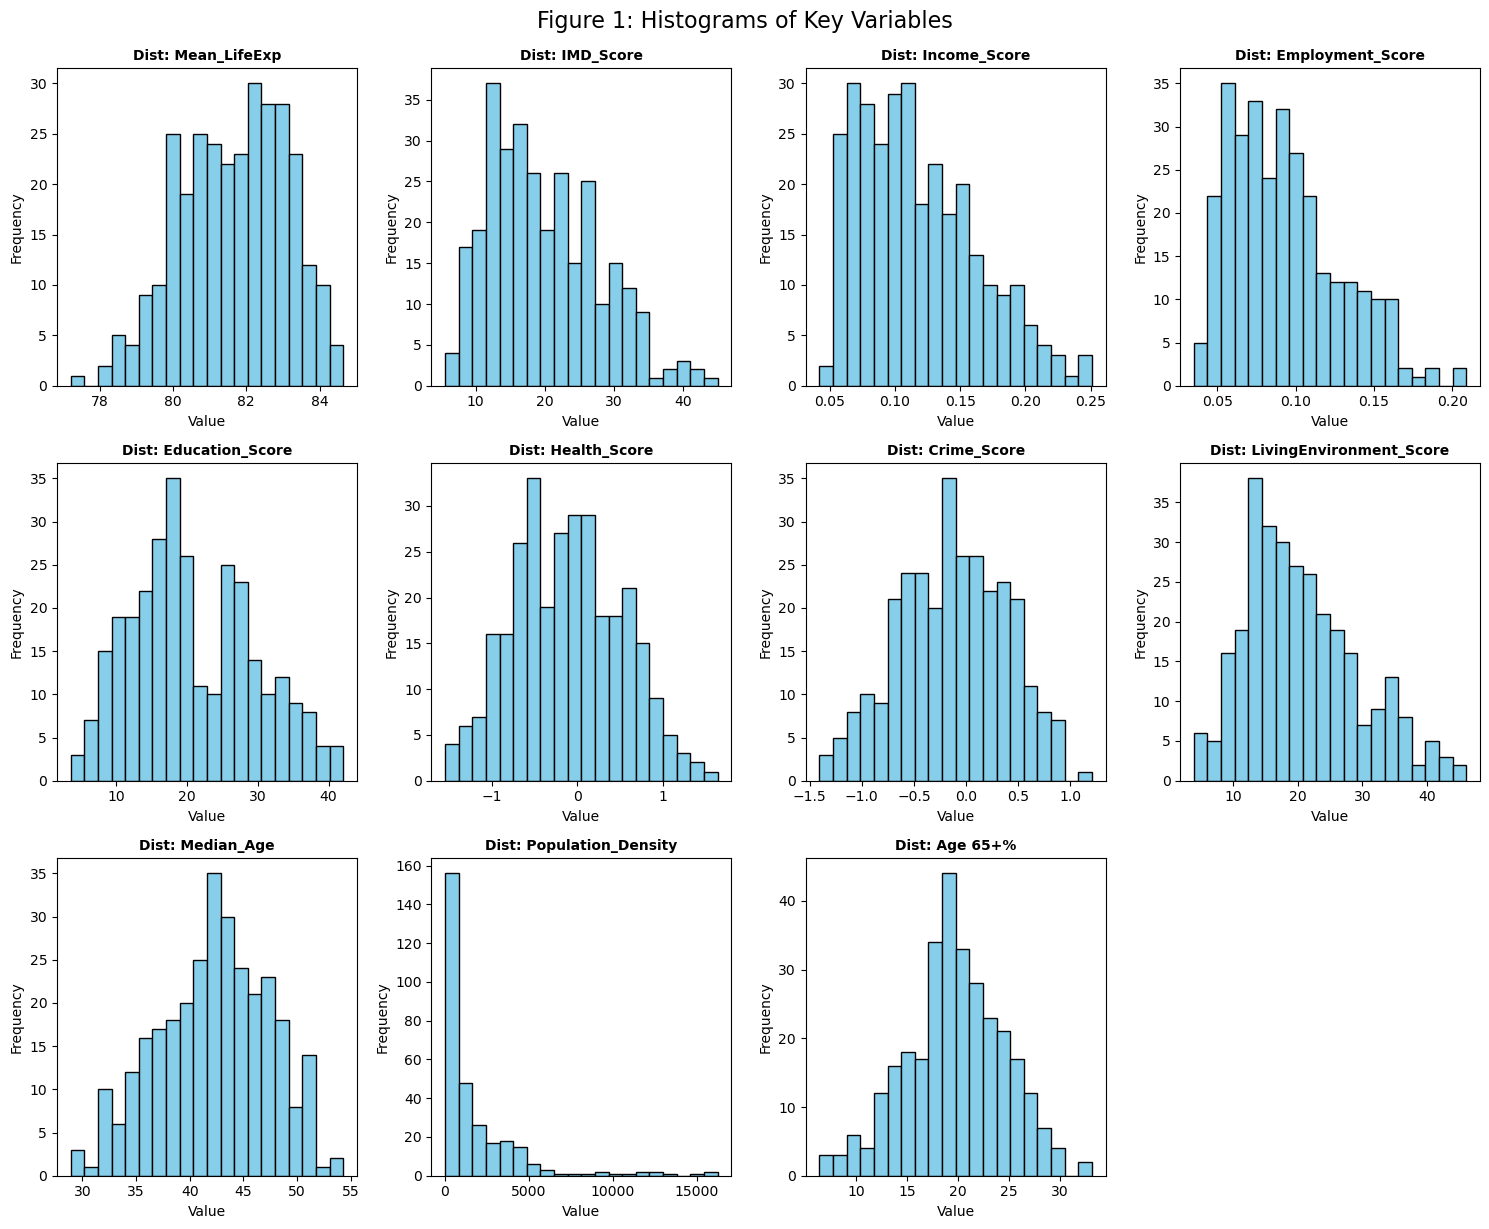

In [314]:
# HISTOGRAMS 
# Use the numeric_cols list created earlier
# Goal: To see if data is 'Normal' (Bell-shaped) or 'Skewed' (Leaning left/right).

# Import matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12)) # Set the canvas size (Width, Height)

# Loop through each variable to create a subplot
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i + 1) # Create a grid (3 rows, 4 columns)
    
    # Plot the histogram
    # bins = 20: Divides data into 20 bars to show detail
    # color = 'skyblue': Standard academic colour for neutrality
    # edgecolor = 'black': Adds borders to make bars distinct
    plt.hist(Main_Dataset[col], bins = 20, color = 'skyblue', edgecolor = 'black')
    
    # Add titles and labels
    plt.title(f'Dist: {col}', fontsize=10, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust spacing so graphs don't overlap
plt.suptitle('Figure 1: Histograms of Key Variables', fontsize = 16, y = 1.02) # Master Title
plt.savefig("Histograms.png", dpi=300, bbox_inches='tight')
plt.show()

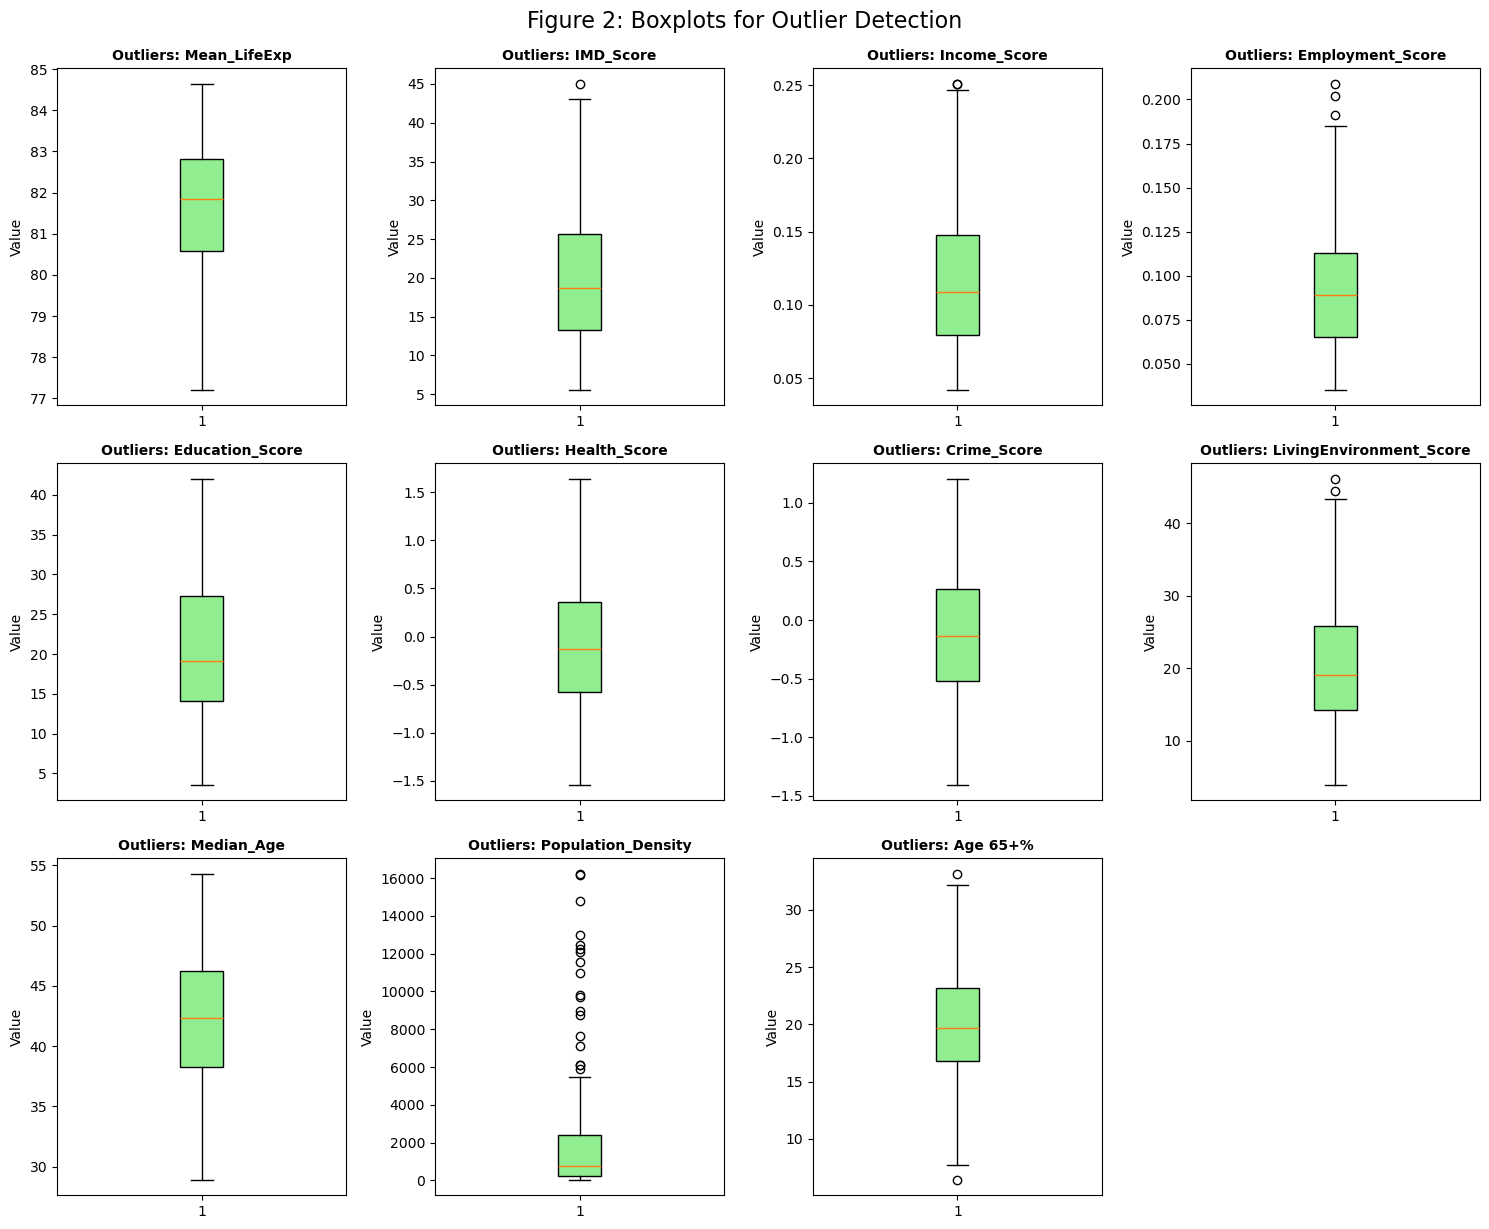

In [315]:
# BOXPLOTS 
# Goal: To visually identify extreme values (circles outside the box whiskers).
# Outliers can distort regression lines, so need to be visually checked for 

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_cols):
    plt.subplot(3, 4, i + 1)
    
    # Plot Boxplot
    # vert=True: Vertical boxplot
    # patch_artist=True: Fills the box with colour
    plt.boxplot(Main_Dataset[col], vert=True, patch_artist=True, 
                boxprops=dict(facecolor="lightgreen"))
    
    plt.title(f'Outliers: {col}', fontsize=10, fontweight='bold')
    plt.ylabel('Value')

plt.tight_layout()
plt.suptitle('Figure 2: Boxplots for Outlier Detection', fontsize=16, y=1.02)
plt.savefig("Boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

**SPATIAL DISTRIBUTION OF LIFE EXPECTANCY IN ENGLAND, 2019**

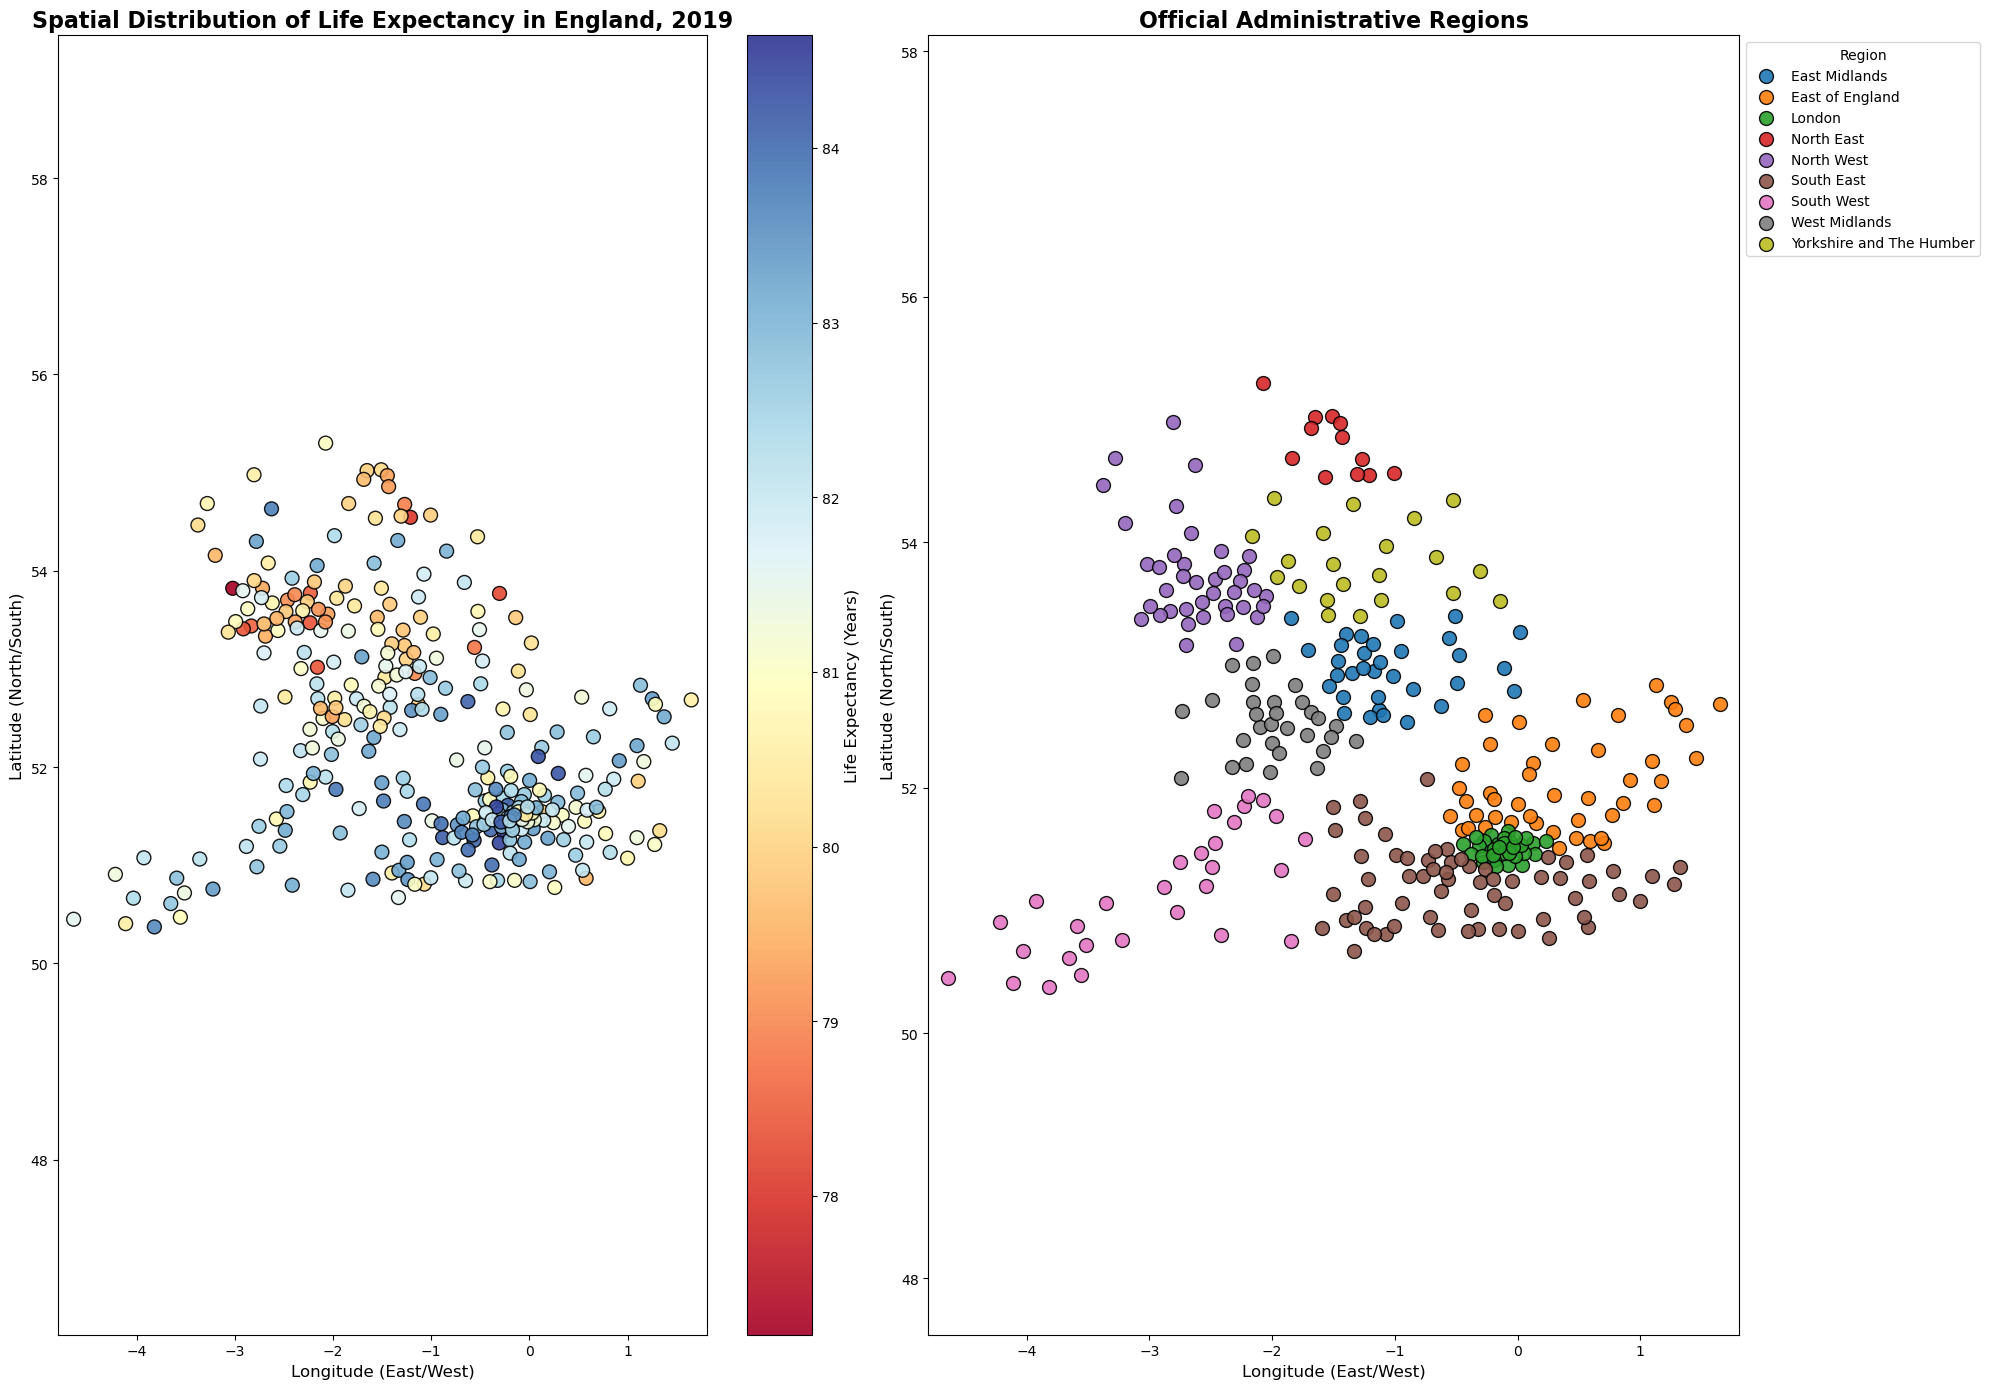

In [317]:
# Setup the canvas
# Define the canvas size (20 width, 12 height)
plt.figure(figsize=(20, 14))


# Map A: Spatial Distribution of Life Expectancy in England, 2019 (LEFT)
# Determine the positioning of the map (1 row, 2 cols, Position 1)
plt.subplot(1, 2, 1)

# Draw the scatter plot
# 'c' = colour the dots based on the 'Mean_LifeExp' column (Numbers)
# 'cmap' = set the colour scheme to Red-Yellow-Blue
scatter_plot = plt.scatter(
    x = Main_Dataset['Longitude'], 
    y = Main_Dataset['Latitude'], 
    c = Main_Dataset['Mean_LifeExp'], 
    cmap = 'RdYlBu', 
    s = 100,                 # Sets the size of the dots to 100
    edgecolors = 'black',    # Adds a black border around each dot
    alpha = 0.9)             # Makes dots slightly see-through (0.9 opacity)

# Add the Colourbar (Legend for numbers)
# Attach it to the 'scatter_plot' we just made
cbar = plt.colorbar(scatter_plot)
cbar.set_label('Life Expectancy (Years)', fontsize=12)     # Label the bar

# Add a title
plt.title("Spatial Distribution of Life Expectancy in England, 2019", fontsize=16, fontweight='bold')
# Add the x-axis label 
plt.xlabel("Longitude (East/West)", fontsize=12)
# Add the y-axis label
plt.ylabel("Latitude (North/South)", fontsize=12)
# Set the aspect ratio to 'equal' so the UK map isn't stretched
plt.axis('equal')


# MAP B: Regions in England (RIGHT)
# Determine the positioning of the graph (1 row, 2 cols, Position 2)
plt.subplot(1, 2, 2)

# Use a loop to plot each region one by one
# Loop through every unique Region in the dataset
for region_name, region_data in Main_Dataset.groupby('Region'):
    plt.scatter(
        x = region_data['Longitude'], 
        y = region_data['Latitude'], 
        label = region_name,     # Allocates the variable for the legend
        s = 100,                 # Size of dots
        edgecolors = 'black',    # Black border
        alpha = 0.9)             # Transparency

# Add a title 
plt.title("Official Administrative Regions", fontsize=16, fontweight='bold')
# Add the x-axis label 
plt.xlabel("Longitude (East/West)", fontsize=12)
# Add the y-axis label 
plt.ylabel("Latitude (North/South)", fontsize=12)

# Add the Legend (Key)
# 'bbox_to_anchor' moves it outside the map so it doesn't cover the data
plt.legend(title='Region', loc='upper left', bbox_to_anchor=(1, 1))

# Set the aspect ratio to 'equal' so the UK map isn't stretched
plt.axis('equal')

# Automatically adjusts the spacing between the two maps so labels don't overlap
plt.tight_layout()

plt.savefig("Spatial_Distribution_LifeExp.png", dpi=300, bbox_inches='tight')

# Show the maps
plt.show()

**THE NATURAL DIVIDE (K-MEANS DERIVED), 2019**

Cluster Centroids: 80.37 years (Low) | 82.80 years (High)
Derived Natural Threshold: 81.5821 years
Geographic Boundary Equation: Latitude = 0.22 * Longitude + 52.80


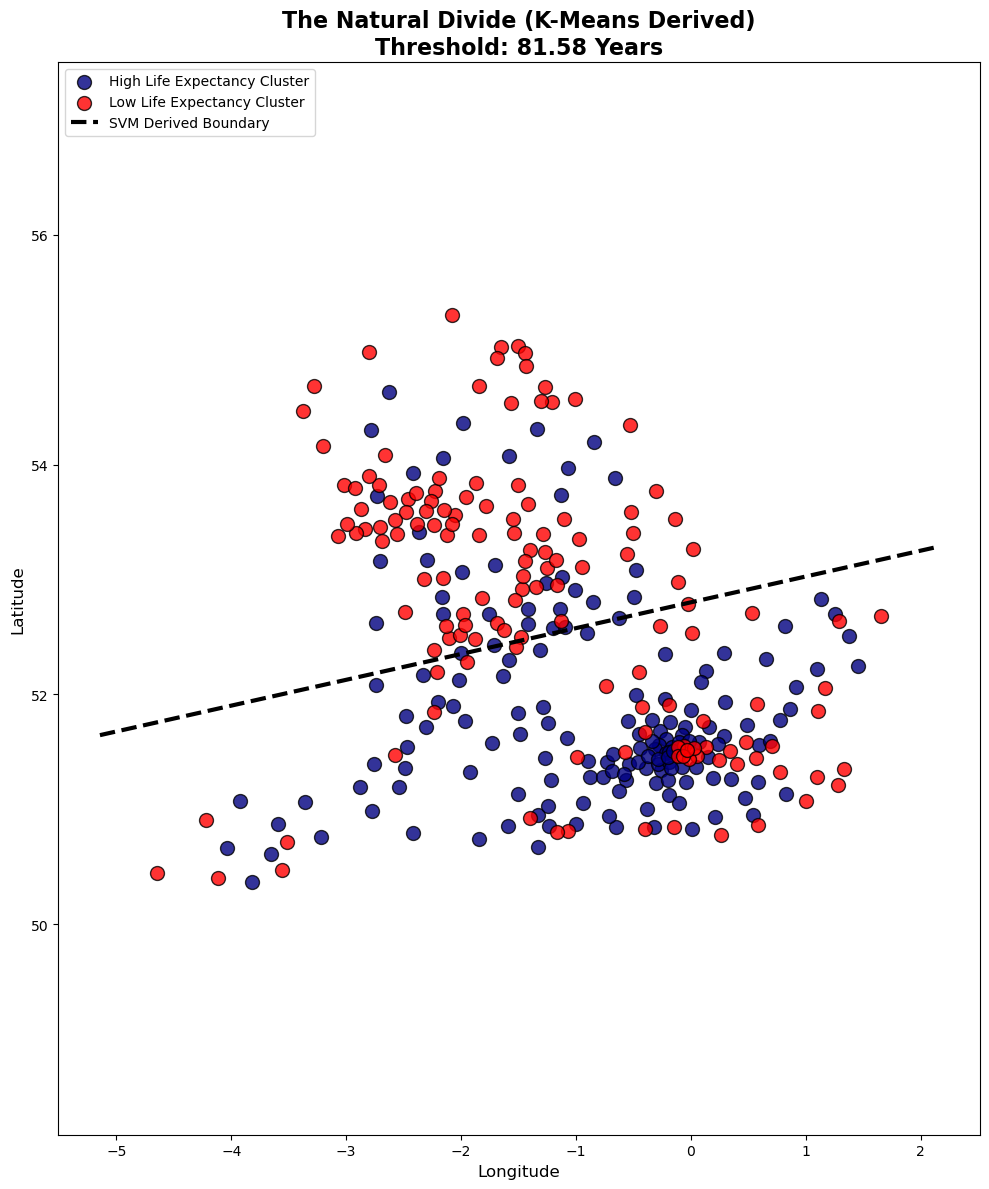

In [319]:
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC

''' Use K-means (unsupervised learning) to identify clusters in life expectancy across England in 2019 
rather than using a threshold like the national average life expectancy in England in 2019 which could be heavily biased and skewed''' 

# Run K-means algorithm 
# Hypothesise two distinct groups - high life expectancy and low life expectancy using: n_clusters = 2 
# Run the algorithm 10 times to ensure convergence on the best centroid: n_init = 10
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the model to the 'Mean_LifeExp' variable
# .values.reshape(-1, 1) is required because Scikit-Learn expects a 2D array for features
Main_Dataset['Cluster_Label'] = kmeans.fit_predict(Main_Dataset['Mean_LifeExp'].values.reshape(-1, 1))

# Derive the statistical threshold 
# Retrieve the centroids (the mean of each cluster)
centroids = sorted(kmeans.cluster_centers_.flatten())

# Calculate the average of the two cluster centres
# This gives the exact halfway point (midpoint) to split 'High' from 'Low'.
natural_threshold = sum(centroids) / 2

print(f"Cluster Centroids: {centroids[0]:.2f} years (Low) | {centroids[1]:.2f} years (High)")
print(f"Derived Natural Threshold: {natural_threshold:.4f} years")

# Support Vector Machines (SVM) Boundary (Supervised learning)
# Define the target variable
    # Convert the continuous Life Expectancy into a binary classification target based on our new threshold
    # 1 = High Life Expectancy Group, 0 = Low Life Expectancy Group
Main_Dataset['Target_Class'] = (Main_Dataset['Mean_LifeExp'] >= natural_threshold).astype(int)

# Train linear support vector machine (SVM)
# Use a linea svm to find the optimal line that separated the two groups 
    # Features (X): Longitude and Latitude
    # Target (y): The Mean_LifeExp (High/Low)
X = Main_Dataset[['Longitude', 'Latitude']]
y = Main_Dataset['Target_Class']

# C = 10.0: A high regularisation parameter imposes a 'hard margin', forcing the model to respect the separation as strictly as possible, 
# minimising misclassification.
svm_model = LinearSVC(C=10.0, dual="auto", random_state=42)
svm_model.fit(X, y)

# Extract the decision boundary 
# The SVM learns a hyperplane equation: w1*x + w2*y + b = 0
    # Rearrange this into standard linear form (y = mx + c) to plot it on the map.
    # Latitude = (Slope * Longitude) + Intercept
w = svm_model.coef_[0]        # Coefficients for Longitude and Latitude
b = svm_model.intercept_[0]   # The bias term

slope = -w[0] / w[1]
intercept = -b / w[1]

print(f"Geographic Boundary Equation: Latitude = {slope:.2f} * Longitude + {intercept:.2f}")

# Setup the canvas
plt.figure(figsize=(10, 12))

# Split the data into two subsets to plot them with distinct colours and labels.
high_group = Main_Dataset[Main_Dataset['Target_Class'] == 1]
low_group = Main_Dataset[Main_Dataset['Target_Class'] == 0]

# Plot the 'High Life Expectancy' Cluster (Blue)
plt.scatter(
    x = high_group['Longitude'], 
    y = high_group['Latitude'], 
    color = 'navy',       # Blue #1f77b4
    label = 'High Life Expectancy Cluster', 
    s = 100,                 # Marker size
    edgecolors = 'black',    # Add border for clarity
    alpha = 0.8)              # Slight transparency


# Plot the 'Low Life Expectancy' Cluster (Red)
plt.scatter(
    x = low_group['Longitude'], 
    y = low_group['Latitude'], 
    color = 'red',       # Red #d62728
    label = 'Low Life Expectancy Cluster', 
    s = 100, 
    edgecolors = 'black', 
    alpha = 0.8)

# Plot the decision boundary 
# Create a range of X values (Longitude) spanning the entire map width
x_vals = np.array([Main_Dataset['Longitude'].min() - 0.5, Main_Dataset['Longitude'].max() + 0.5])

# Calculate corresponding Y values (Latitude) using the SVM equation
y_vals = slope * x_vals + intercept

# Plot the line
plt.plot(
    x_vals, y_vals, 
    color = 'black', 
    linestyle = '--', 
    linewidth = 3, 
    label = 'SVM Derived Boundary')

# Add a Title 
plt.title(f"The Natural Divide (K-Means Derived)\nThreshold: {natural_threshold:.2f} Years", fontsize=16, fontweight='bold')
# Add x-axis label
plt.xlabel("Longitude", fontsize=12)
# Add y-axis label 
plt.ylabel("Latitude", fontsize=12)

# Enforce equal aspect ratio so the map of England isn't distorted
plt.axis('equal')

# Add Legend
plt.legend(loc='upper left', fontsize=10)

# Display the final plot
plt.tight_layout()
plt.savefig("K-means_Map.png", dpi=300, bbox_inches='tight')
plt.show()

**HETEROGENEITY (ANOMALY) ANALYSIS**

--- Heterogeneity Distribution ---
Heterogeneity
Expected Trend                215
Anomaly: Low-Health South      54
Anomaly: High-Health North     35
Name: count, dtype: int64


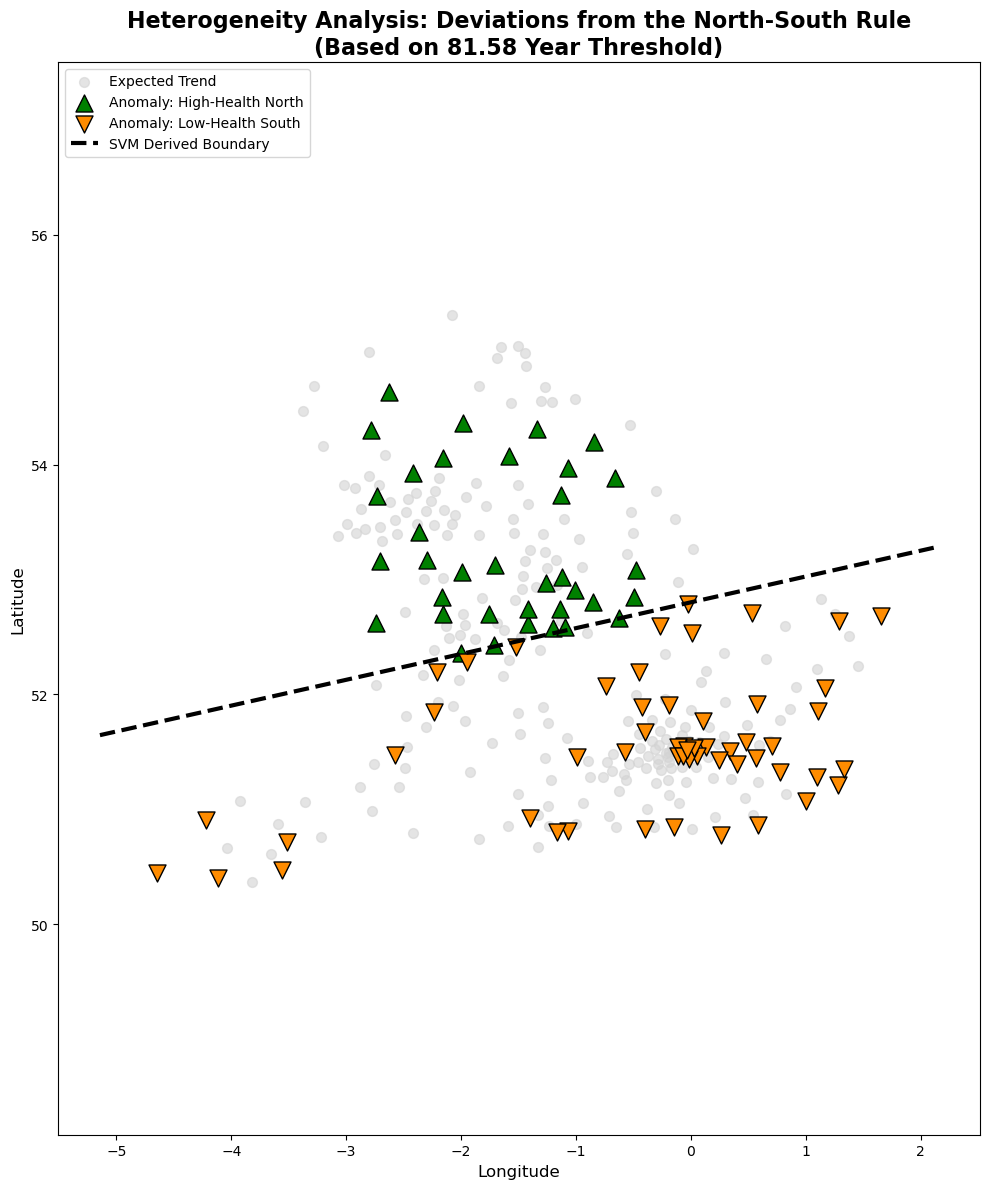

In [321]:
# Identify the geographic location 
    # Verify if a Local Authority is physically 'North' or 'South' of the SVM boundary.
    # Logic: If the Authority's Latitude is higher (>) than the Line's Latitude at that Longitude, it is North.
Main_Dataset['Geo_Location'] = np.where(Main_Dataset['Latitude'] > (slope * Main_Dataset['Longitude'] + intercept), 'North', 'South')

# Classify anomalies 
# Cross-reference the Geographic Location with the life_expectancy (Target_Class).
# Target_Class 1 = High Life Expectancy (Cluster 1)
# Target_Class 0 = Low Life Expectancy (Cluster 0)

conditions = [
    # ANOMALY 1: The "Rich North"
    # Geographically North, but belongs to the High Life Expectancy Cluster.
    (Main_Dataset['Geo_Location'] == 'North') & (Main_Dataset['Target_Class'] == 1),

    # ANOMALY 2: The "Poor South"
    # Geographically South, but belongs to the Low Life Expectancy Cluster.
    (Main_Dataset['Geo_Location'] == 'South') & (Main_Dataset['Target_Class'] == 0),

    # EXPECTED TRENDS (Conform to the North-South hypothesis)
    (Main_Dataset['Geo_Location'] == 'North') & (Main_Dataset['Target_Class'] == 0),
    (Main_Dataset['Geo_Location'] == 'South') & (Main_Dataset['Target_Class'] == 1)]

labels = [
    'Anomaly: High-Health North',
    'Anomaly: Low-Health South',
    'Expected Trend',
    'Expected Trend']

# Apply these labels to a new column for visualisation
Main_Dataset['Heterogeneity'] = np.select(conditions, labels, default='Expected Trend')

# Print counts to quantify the 'complexity' for your report
print("--- Heterogeneity Distribution ---")
print(Main_Dataset['Heterogeneity'].value_counts())

# Setup the canvas size
plt.figure(figsize=(10, 12))

# Plot the expected trends 
expected_group = Main_Dataset[Main_Dataset['Heterogeneity'] == 'Expected Trend']
plt.scatter(
    x = expected_group['Longitude'],
    y = expected_group['Latitude'],
    color = 'lightgrey',
    label = 'Expected Trend',
    s = 50,
    alpha = 0.6)

# Plot the areas with high life expectancy in the North (Target_Class 1)
rich_north = Main_Dataset[Main_Dataset['Heterogeneity'] == 'Anomaly: High-Health North']
plt.scatter(
    x = rich_north['Longitude'],
    y = rich_north['Latitude'],
    color = 'green',
    label = 'Anomaly: High-Health North',
    s = 150,           # Larger size for emphasis
    marker = '^',      # Triangle pointing up
    edgecolors = 'black')

# Plot the areas with low life expectancy in the North (Target_Class 0)
poor_south = Main_Dataset[Main_Dataset['Heterogeneity'] == 'Anomaly: Low-Health South']
plt.scatter(
    x = poor_south['Longitude'],
    y = poor_south['Latitude'],
    color = 'darkorange',
    label = 'Anomaly: Low-Health South',
    s = 150,
    marker = 'v',      # Triangle pointing down
    edgecolors = 'black')

# Plot the SVM line 
x_line = np.array([Main_Dataset['Longitude'].min() - 0.5, Main_Dataset['Longitude'].max() + 0.5])
y_line = slope * x_line + intercept

plt.plot(
    x_line, y_line,
    color = 'black',
    linestyle = '--',
    linewidth = 3,
    label = 'SVM Derived Boundary')

# Add a graph title 
plt.title(f"Heterogeneity Analysis: Deviations from the North-South Rule\n(Based on {natural_threshold:.2f} Year Threshold)", fontsize=16, fontweight='bold')
# Add a x-axis label
plt.xlabel("Longitude", fontsize=12)
# Add a y-axis label 
plt.ylabel("Latitude", fontsize=12)

# Enforce equal aspect ratio to maintain the correct shape of England
plt.axis('equal')

# Clean up spines (remove top and right borders) for a cleaner academic look
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

# Place legend outside the plot area to prevent obscuring data points
#plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=10)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig("Heterogeneity_Map.png", dpi=300, bbox_inches='tight')
plt.show()

**SPATIAL DISTRIBUTION OF IMD AVERAGE SCORE IN ENGLAND, 2019**

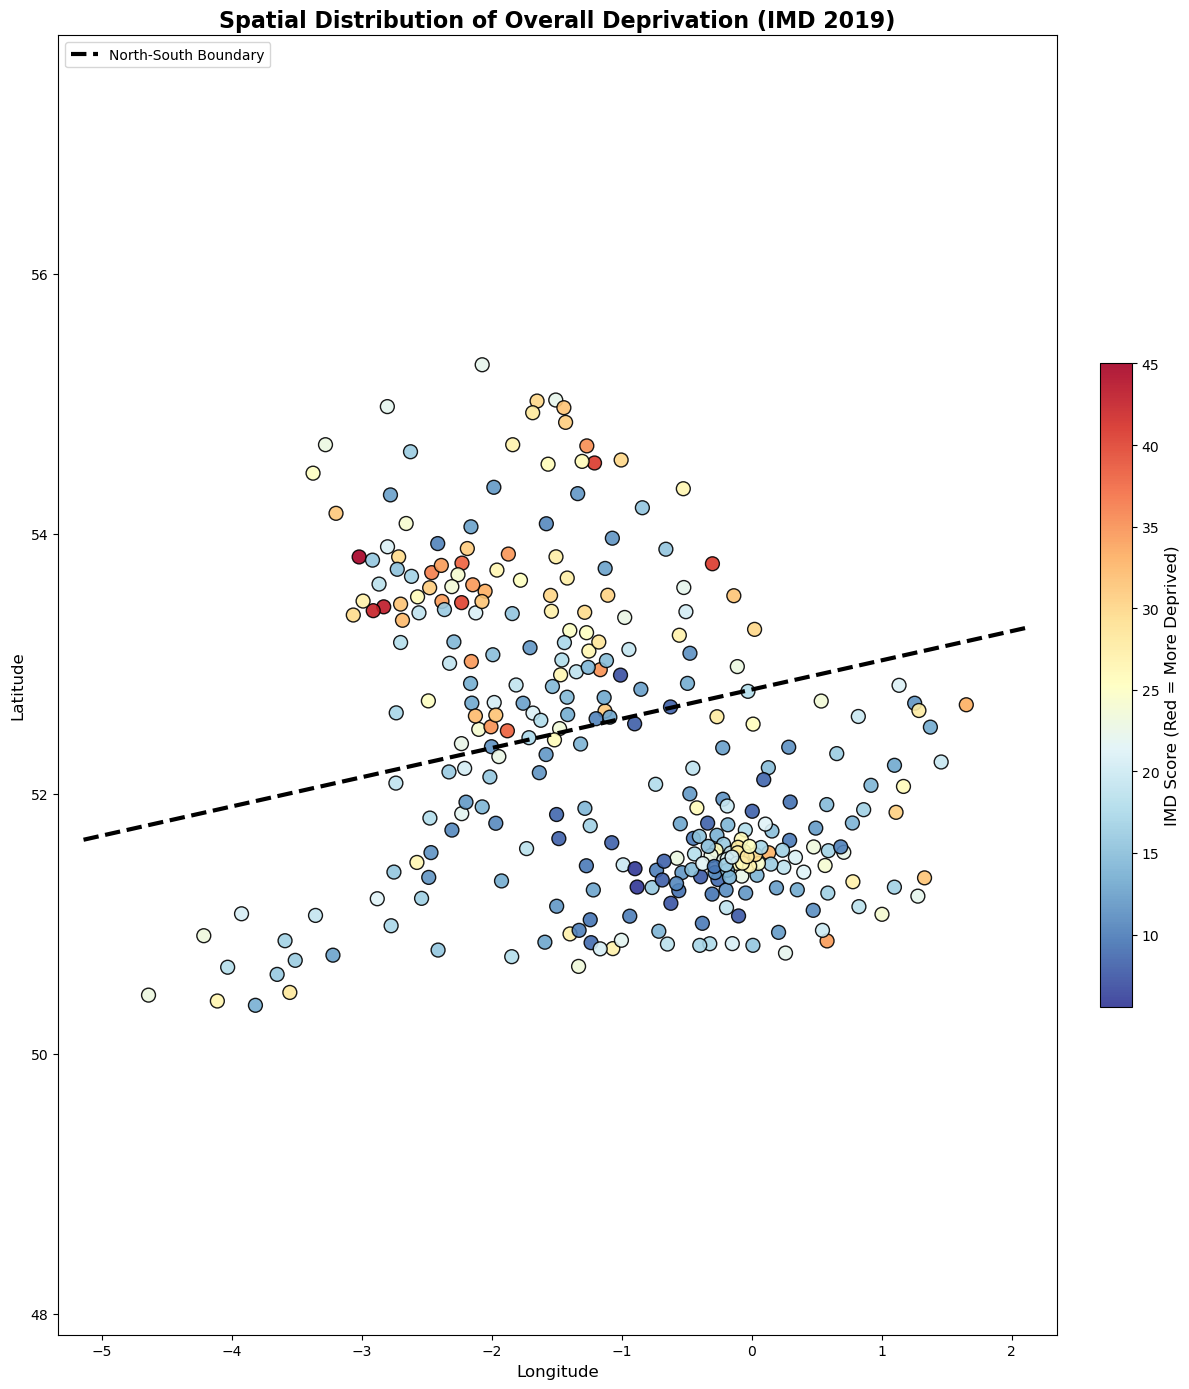

In [323]:
# Setup Canvas
plt.figure(figsize=(12, 14))

# Plot the IMD Average Score
# Use 'RdYlBu_r' (Reversed) so Red = High Score (More Deprived)
scatter = plt.scatter(
    x = Main_Dataset['Longitude'], 
    y = Main_Dataset['Latitude'], 
    c = Main_Dataset['IMD_Score'], 
    cmap = 'RdYlBu_r', 
    s = 100, 
    edgecolors = 'black', 
    alpha = 0.9)

# Add the SVM line
# Calculate line coordinates based on map width
x_line = np.array([Main_Dataset['Longitude'].min() - 0.5, Main_Dataset['Longitude'].max() + 0.5])
y_line = slope * x_line + intercept

plt.plot(x_line, y_line, color = 'black', linestyle = '--', linewidth=3, label = 'North-South Boundary')

# Add Colorbar
cbar = plt.colorbar(scatter, fraction=0.03, pad=0.04)
cbar.set_label('IMD Score (Red = More Deprived)', fontsize=12)

# Format the map
plt.title("Spatial Distribution of Overall Deprivation (IMD 2019)", fontsize = 16, fontweight = 'bold')
plt.xlabel("Longitude", fontsize = 12)
plt.ylabel("Latitude", fontsize = 12)
plt.legend(loc = 'upper left')
plt.axis('equal')

# Remove box borders
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("Spatial_Distribution_Map_IMDAvgScore.png", dpi=300, bbox_inches='tight')
plt.show()

**SPATIAL DISTRIBUTION OF IMD SUB-DOMAINS IN ENGLAND, 2019**

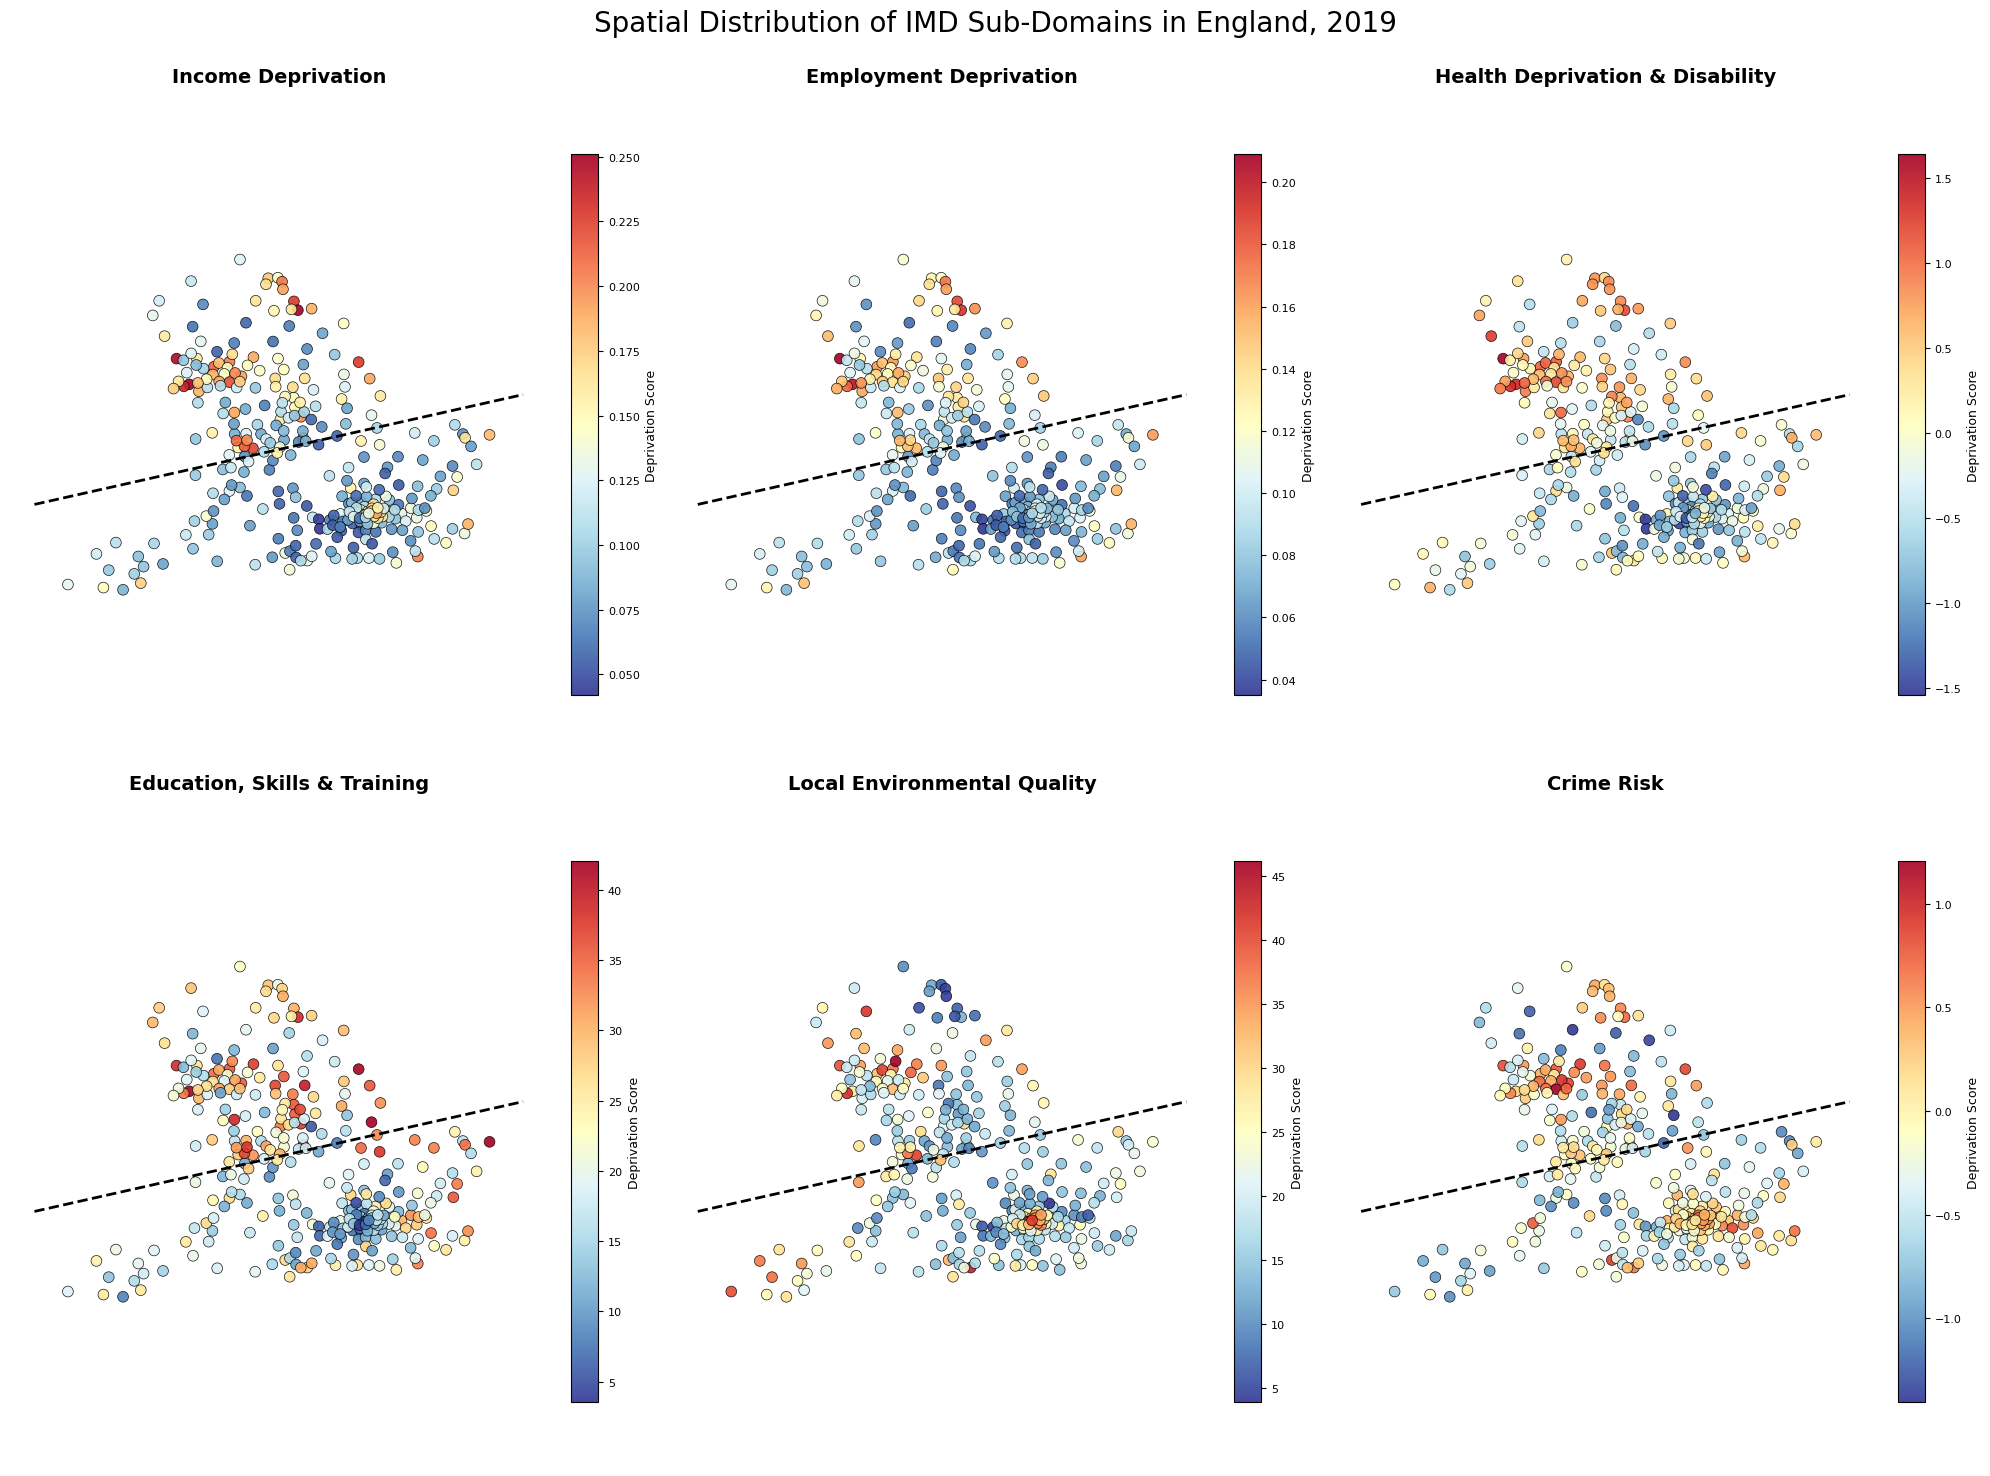

In [325]:
# Define the subdomains
subdomains = [
    ('Income_Score', 'Income Deprivation'),
    ('Employment_Score', 'Employment Deprivation'),
    ('Health_Score', 'Health Deprivation & Disability'),
    ('Education_Score', 'Education, Skills & Training'),
    ('LivingEnvironment_Score', 'Local Environmental Quality'),
    ('Crime_Score', 'Crime Risk')]


# Setup the figure canvas
plt.figure(figsize=(20, 16))

# Loop the subdomains 
for i, (col_name, title) in enumerate(subdomains):
    
    # Select a specific subplot position (2 rows, 3 columns)
    plt.subplot(2, 3, i + 1)
    
    # Check if column exists
    if col_name in Main_Dataset.columns:
        
        # Create a scatter map 
        # Assign the plot to a variable 'sc' to create the colorbar later
        sc = plt.scatter(
            x = Main_Dataset['Longitude'], 
            y = Main_Dataset['Latitude'], 
            c = Main_Dataset[col_name], 
            cmap = 'RdYlBu_r',     # Red = High Score (More Deprived)
            s = 60, 
            edgecolors = 'black', 
            linewidth = 0.5,
            alpha = 0.9)
        
        # Add the SVM line
        # Calculate line coordinates based on map width
        x_line = np.array([Main_Dataset['Longitude'].min() - 0.5, Main_Dataset['Longitude'].max() + 0.5])
        y_line = slope * x_line + intercept
        
        # Draw the North-South Line
        plt.plot(x_line, y_line, color='black', linestyle='--', linewidth=2, label='North-South Divide')
        
        # Format the map
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('equal')  # Force correct UK shape
        plt.axis('off')    # Hide axis box
        
        # Add the legend (colourbar) 
        cbar = plt.colorbar(sc, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label('Deprivation Score', fontsize=9)
        
    #else:
        # Fallback for missing columns
        #plt.text(0.5, 0.5, f"Column '{col_name}' not found", ha='center')
        #plt.axis('off')

# Display the figure 
plt.suptitle('Spatial Distribution of IMD Sub-Domains in England, 2019', fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Spatial_Distribution_Map_IMD_Subdomains.png", dpi=300, bbox_inches='tight')
plt.show()

**T-TEST OF SVM BOUNDARY TO TEST FOR THE SIGNIFICANCE OF THE NORTH/SOUTH DIVIDE**

In [327]:
# Import the necessary library for ttest
from scipy.stats import ttest_ind

# Assign the geographic region based on the SVM Boundary 
# Use the SVM model to predict which side of the line every local authority falls under - North/South
    # Only select Latitude and Longitude since SVM was trained on them 
Spatialfeatures = Main_Dataset[['Longitude', 'Latitude']]
   
    # Use the SVM model to classify every local authority into Region 1 or region 0 based on the claculated SVM boundary line
Main_Dataset['Region_Predicted'] = svm_model.predict(Spatialfeatures)


# Identify local authority into either North or South 
# The SVM outputs '0' and '1', but we don't know which is North yet.
# Calculate the average Latitude for both groups.
avg_latitude = Main_Dataset.groupby('Region_Predicted')['Latitude'].mean()

# Check which group has the higher latitude (Higher Latitude = Further North)
if avg_latitude[0] > avg_latitude[1]:
    # If Group 0 is higher up the map, label it North
    north_code = 0
    south_code = 1
else:
    # Otherwise, Group 1 is North
    north_code = 1
    south_code = 0

print(f"Geography Defined: Group {north_code} is NORTH, Group {south_code} is SOUTH.\n")


# Filter the dataset to get only the Life Expectancy values for the North
# We look at rows where 'Region_Predicted' matches our 'north_code'
north_data = Main_Dataset[Main_Dataset['Region_Predicted'] == north_code]['Mean_LifeExp']

# Filter the dataset to get only the Life Expectancy values for the South
south_data = Main_Dataset[Main_Dataset['Region_Predicted'] == south_code]['Mean_LifeExp']


# Calculate the magnitude of difference in life expectancy between the North and the South local authority 
# Calculate the average Mean_LifeExp in the Northern local authorities 
mean_north = north_data.mean()
# Calculate the average Mean_LifeExp in the southern local authorities
mean_south = south_data.mean()
# Calculate the difference of the two 
gap = mean_south - mean_north

print(f"Average Life Expectancy (North Region): {mean_north:.2f} years")
print(f"Average Life Expectancy (South Region): {mean_south:.2f} years")
print(f"Magnitude of Divide: {gap:.2f} years")

# Run the T-Test (use Welch's T-Test)
t_stat, p_val = ttest_ind(north_data, south_data, equal_var=False)

print("\nSTATISTICAL TEST RESULTS:")
print(f"T-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_val:.5e}")  # Scientific notation for precision

if p_val < 0.05:
    print("\nCONCLUSION: The North-South divide is STATISTICALLY SIGNIFICANT.")
    print("The SVM boundary successfully separates two distinct populations. There is a differrence between the average life expectancy in the North and the South of England in 2019.")
else:
    print("\nCONCLUSION: The divide is not statistically significant.")

Geography Defined: Group 0 is NORTH, Group 1 is SOUTH.

Average Life Expectancy (North Region): 80.70 years
Average Life Expectancy (South Region): 82.29 years
Magnitude of Divide: 1.59 years

STATISTICAL TEST RESULTS:
T-Statistic: -10.752
P-Value: 4.81387e-22

CONCLUSION: The North-South divide is STATISTICALLY SIGNIFICANT.
The SVM boundary successfully separates two distinct populations. There is a differrence between the average life expectancy in the North and the South of England in 2019.


**SCATTER GRAPHS: LIFE_EXPECTANCY VS IMD SUB-DOMAINS**

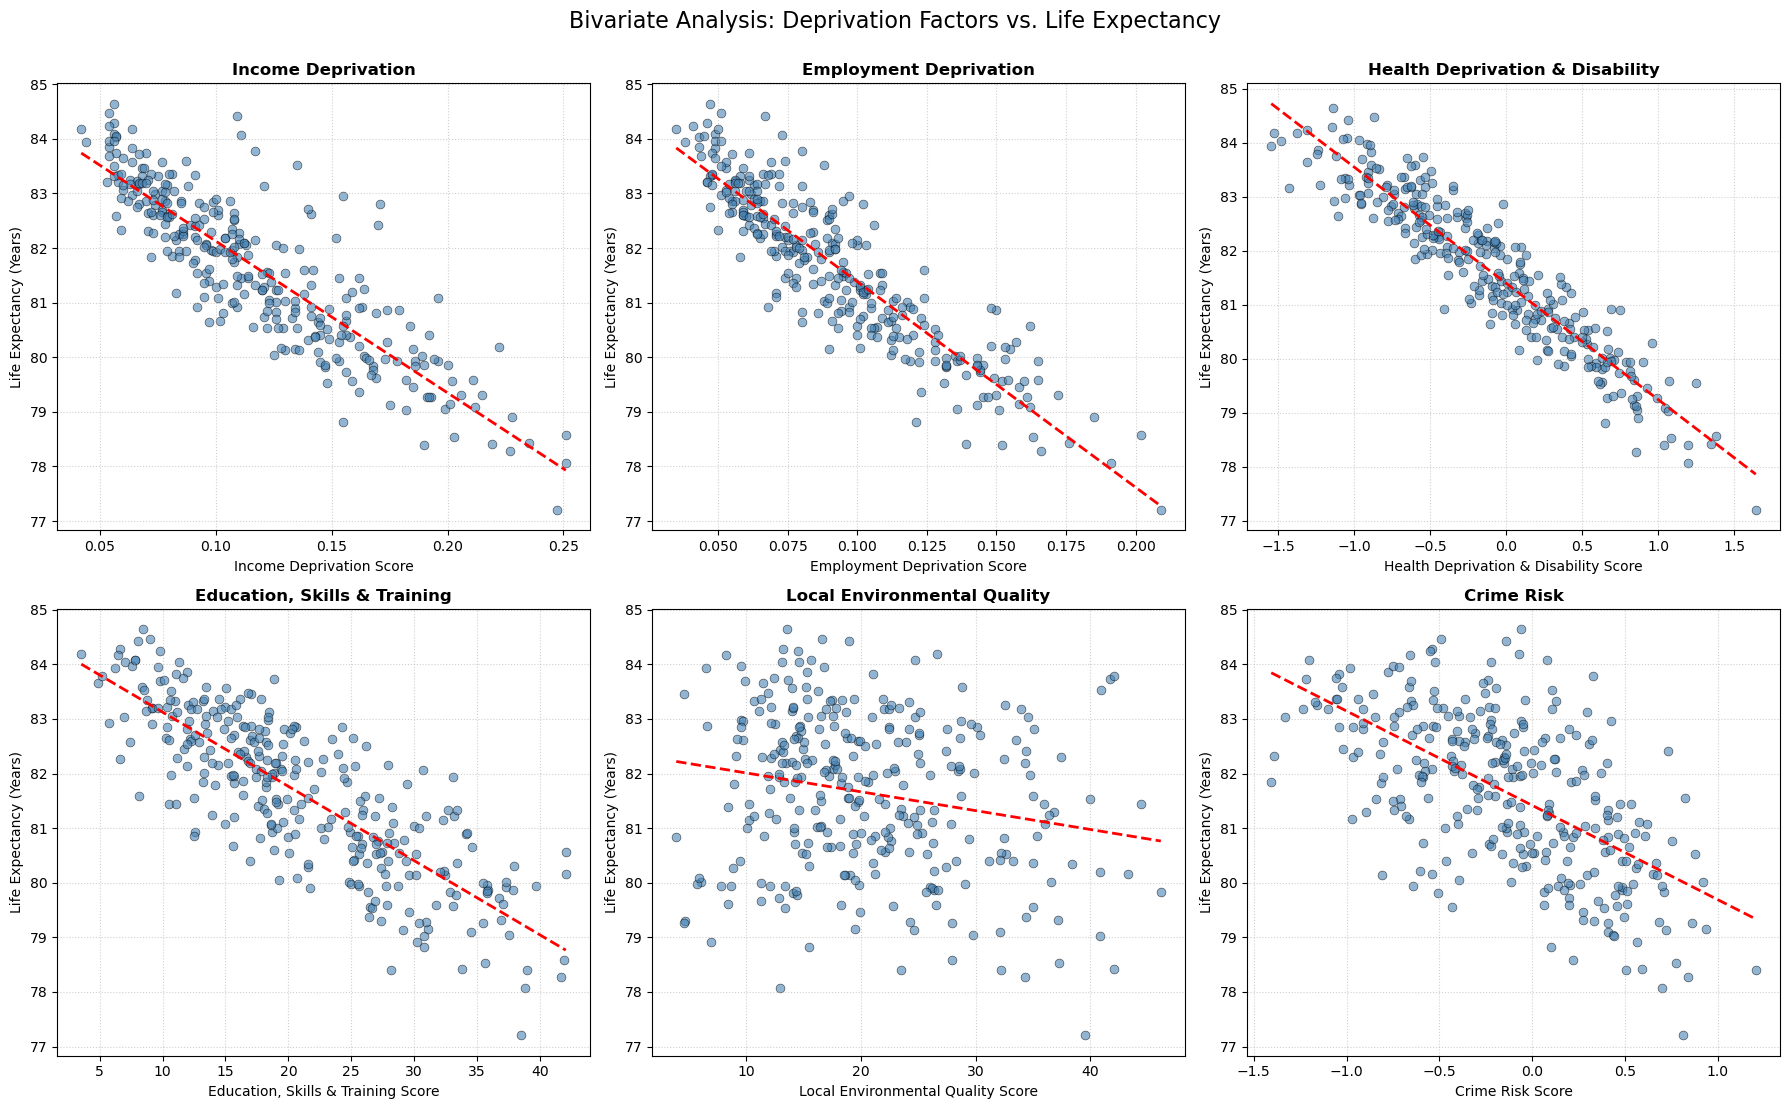

In [329]:
# Use the list of subdomains created earlier 

# Create a large figure (18x12) to hold 6 plots
plt.figure(figsize=(18, 12))

# Loop through the list of variables in 'subdomains'
for i, (col_name, title) in enumerate(subdomains):
    
    # Select the specific subplot position (2 rows, 3 columns)
    # i+1 is needed because subplot numbers start at 1, not 0
    plt.subplot(2, 3, i + 1)
    
    # Check if the column exists in the data
    if col_name in Main_Dataset.columns:
        
        # Plot the data points (Blue dots)
        plt.scatter(
            x = Main_Dataset[col_name], 
            y = Main_Dataset['Mean_LifeExp'], 
            alpha = 0.6,           # Transparency makes dense areas visible
            c = 'steelblue',       # Professional blue color
            edgecolors = 'black',  # Black border for clarity
            linewidths = 0.5,
            s = 40)
        
        # Add a trend line 
        # Calculate the line of best fit (y = mx + c)
        # polyfit returns slope (m) and intercept (c)
        valid = Main_Dataset[[col_name, 'Mean_LifeExp']].dropna()
        if len(valid) > 0:
            m, c = np.polyfit(valid[col_name], valid['Mean_LifeExp'], 1)
            
            # Create coordinates for the red line
            x_vals = np.array([valid[col_name].min(), valid[col_name].max()])
            y_vals = m * x_vals + c
            
            # Plot the line (Red dashed)
            plt.plot(x_vals, y_vals, color = 'red', linestyle = '--', linewidth = 2, label = 'Linear Trend')

        
        # Add titles and labels
        plt.title(title, fontsize = 12, fontweight = 'bold')
        plt.xlabel(f"{title} Score", fontsize = 10)
        plt.ylabel("Life Expectancy (Years)", fontsize = 10)
        plt.grid(True, linestyle = ':', alpha = 0.6) # Add faint grid lines
        
# Add a main title for the whole figure
plt.suptitle('Bivariate Analysis: Deprivation Factors vs. Life Expectancy', fontsize=16, y=0.95)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show the final image
plt.show()

**SCATTER GRAPHS: LIFE EXPECTANCY VS DEMOGRAPHIC VARIABLES**

<Figure size 1600x1200 with 0 Axes>

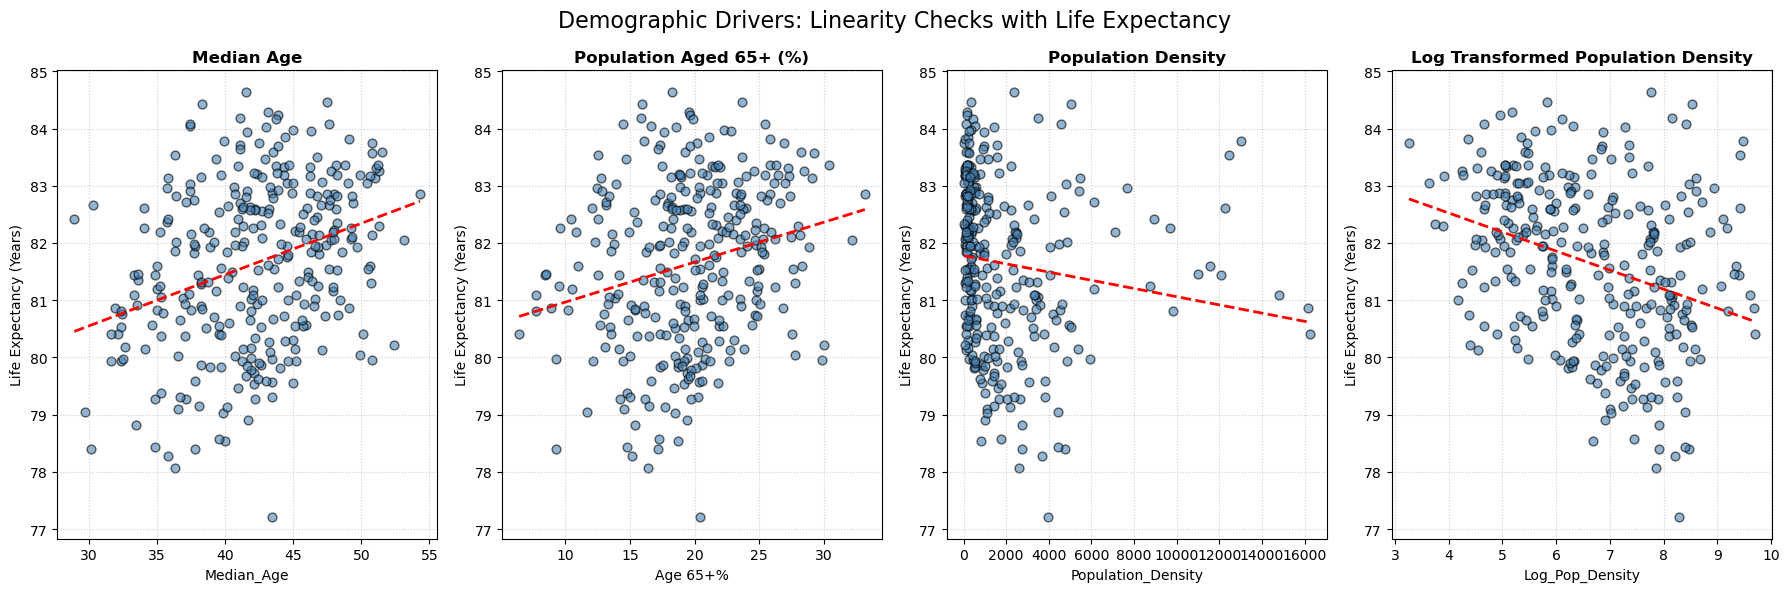

In [331]:
# Create a 2x2 grid (4 plots total).
# figsize=(16, 12) ensures each quadrant is large and readable.
plt.figure(figsize=(16, 12))

# Transform Population Density because it is highly skewed.
# np.log1p calculates log(1 + x) to handle zero values safely.
Main_Dataset['Log_Pop_Density'] = np.log1p(Main_Dataset['Population_Density'])

# Create a list of the demographics for plotting
    # Format: (X-Axis Column Name, Title for the Graph)
    # Include log and normal Population_Density
demographics = [
    ('Median_Age', 'Median Age'),
    ('Age 65+%', 'Population Aged 65+ (%)'),
    ('Population_Density', 'Population Density'),
    ('Log_Pop_Density', 'Log Transformed Population Density')]

# Create a figure wide enough for 4 side-by-side plots.
plt.figure(figsize=(18, 6))

# Loop through the list of demogrphics
for i, (col_name, title) in enumerate(demographics):
    
    # Select the specific subplot position (1 row, 3 columns)
    plt.subplot(1, 4, i + 1)
    
    # Check if column exists
    if col_name in Main_Dataset.columns:
        
        # Plot the scatter graph
        # X = Demographic Variable, Y = Life Expectancy
        plt.scatter(
            x=Main_Dataset[col_name], 
            y=Main_Dataset['Mean_LifeExp'], 
            alpha=0.6,           # Transparency makes overlaps visible
            c='steelblue',       # Color
            edgecolors='black',  # Border
            s=40)
        
        # Add a trend line 
        # Calculate the straight line of best fit (y = mx + c)
        valid = Main_Dataset[[col_name, 'Mean_LifeExp']].dropna()
        
        if len(valid) > 0:
            m, c = np.polyfit(valid[col_name], valid['Mean_LifeExp'], 1)
            
            # Create coordinates for the red line
            x_vals = np.array([valid[col_name].min(), valid[col_name].max()])
            y_vals = m * x_vals + c
            
            # Plot the line (Red dashed)
            plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label='Linear Trend')
        
        # Format the graphs
        plt.title(title, fontsize=12, fontweight='bold')
        plt.xlabel(col_name, fontsize=10)
        plt.ylabel("Life Expectancy (Years)", fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.6) # Add faint grid

# Add a main title for the figure
plt.suptitle('Demographic Drivers: Linearity Checks with Life Expectancy', fontsize=16, y=0.98)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the final graphs
plt.show()

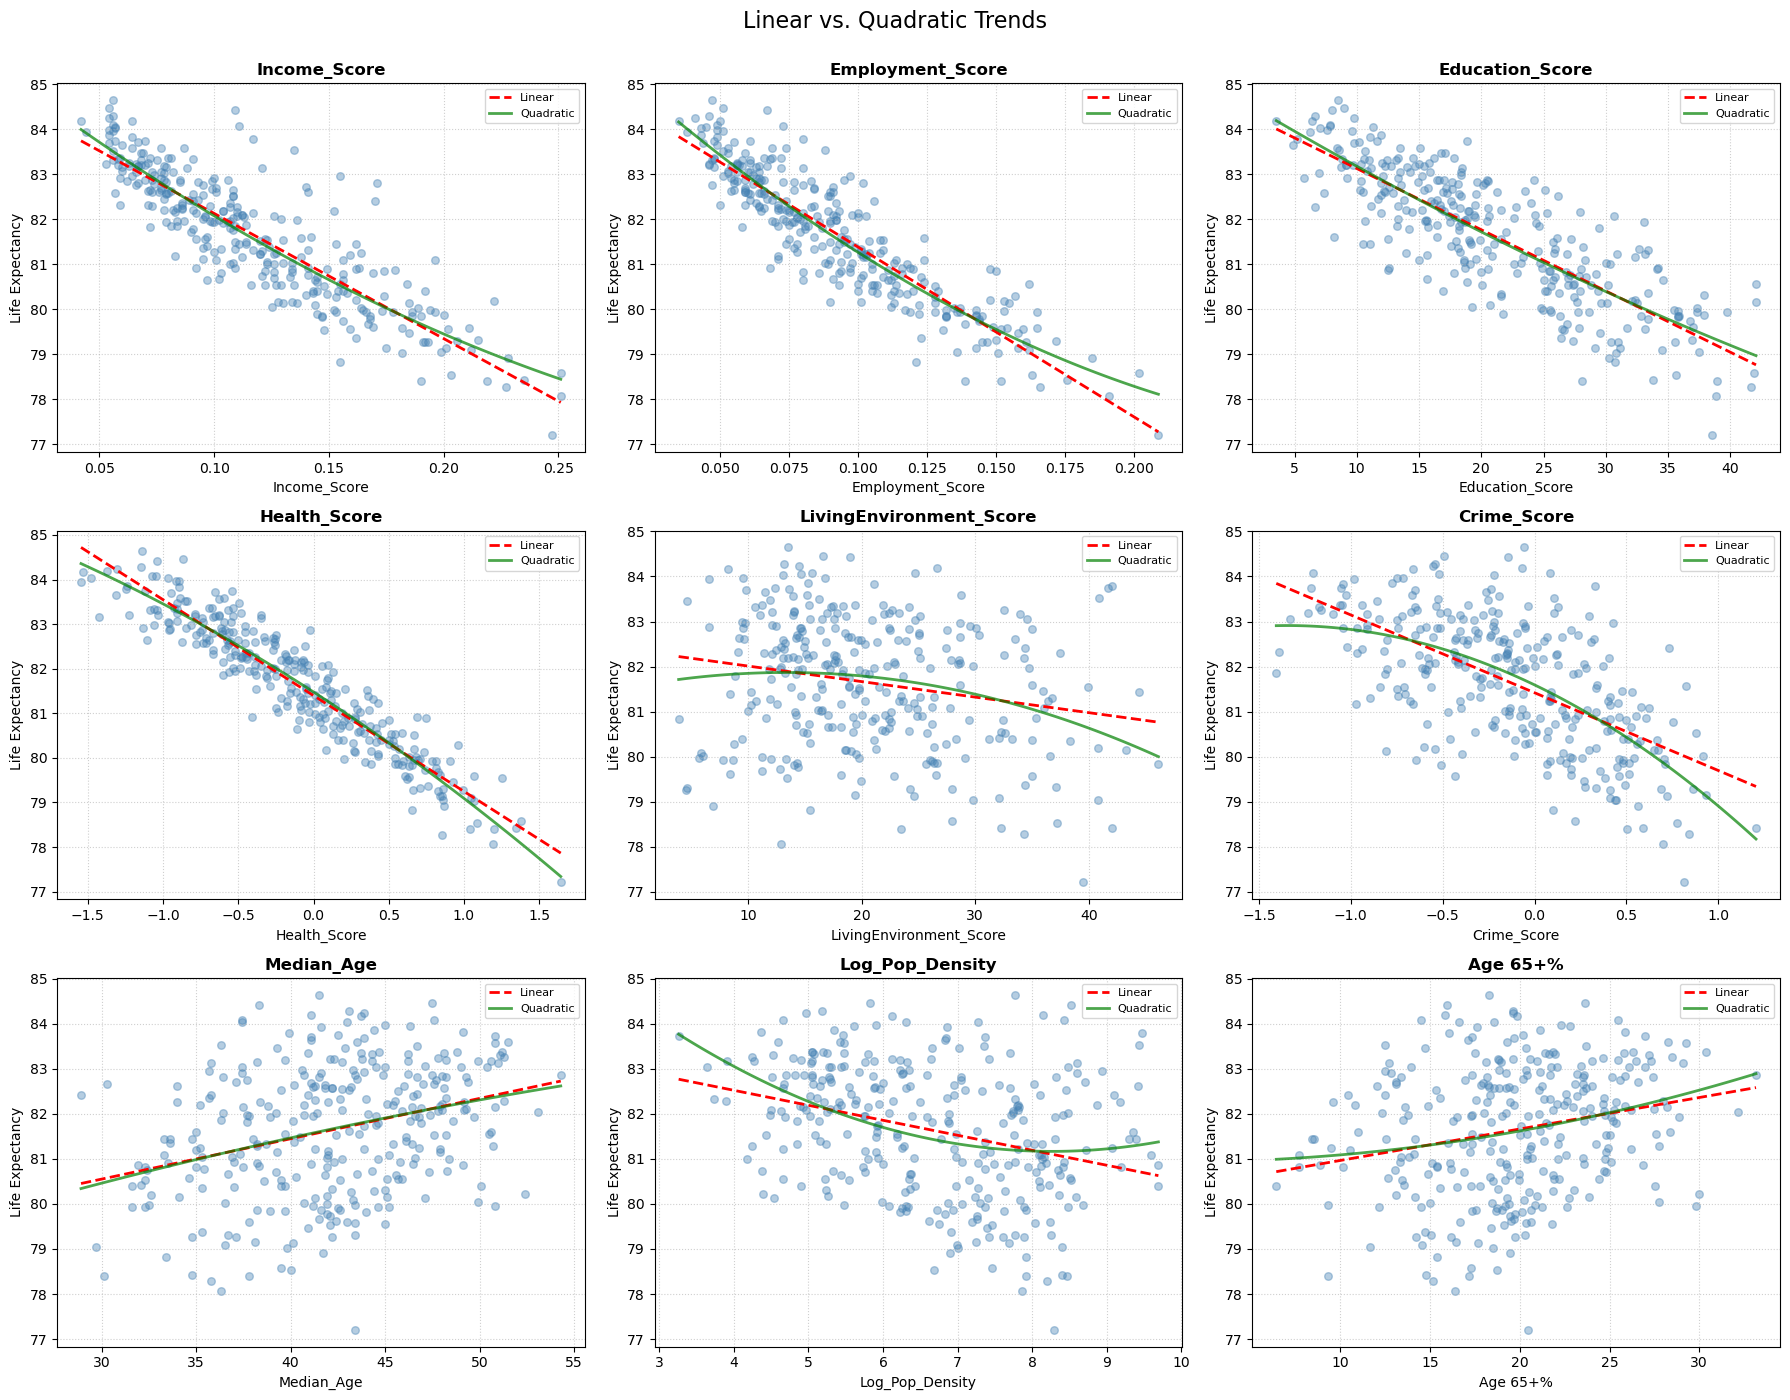

In [332]:
from sklearn.metrics import r2_score

numeric_cols = [
    'Income_Score', 
    'Employment_Score', 
    'Education_Score', 
    'Health_Score', 
    'LivingEnvironment_Score', 
    'Crime_Score',
    'Median_Age',
    'Log_Pop_Density',
    'Age 65+%']

# Set up a figure
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Loop through each vairable in the numeric_cols list
for i, col in enumerate(numeric_cols):
    if i < len(axes) and col in Main_Dataset.columns:
        ax = axes[i]
        
        # Plot the scatter
        ax.scatter(Main_Dataset[col], Main_Dataset['Mean_LifeExp'], alpha=0.4, c='steelblue', s=30)
        
        # Linear Fit (Red Dashed)
        valid = Main_Dataset[[col, 'Mean_LifeExp']].dropna()
        z1 = np.polyfit(valid[col], valid['Mean_LifeExp'], 1)
        p1 = np.poly1d(z1)
        x_range = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_range, p1(x_range), 'r--', linewidth = 2, label = 'Linear')
        
        # Quadratic Fit (Green Solid) - To check curvature
        z2 = np.polyfit(valid[col], valid['Mean_LifeExp'], 2)
        p2 = np.poly1d(z2)
        ax.plot(x_range, p2(x_range), 'g-', linewidth = 2, alpha = 0.7, label = 'Quadratic')
        
        # Format the graph
        ax.set_title(col, fontsize = 12, fontweight = 'bold')
        ax.set_xlabel(col)
        ax.set_ylabel("Life Expectancy")
        ax.legend(loc = 'best', fontsize = 8)
        ax.grid(True, linestyle = ':', alpha = 0.6)

plt.suptitle("Linear vs. Quadratic Trends", fontsize = 16, y = 0.96)
plt.tight_layout(rect = [0, 0.03, 1, 0.96])
plt.savefig("LinearQuadraticTrends.png", dpi=300, bbox_inches='tight')
plt.show()

**CORRELATION ANALYSIS**


Variable: Income_Score
Pearson r: -0.871 (p-value: 3.1368e-95)
Spearman r: -0.866 (p-value: 5.4892e-93)

Variable: Employment_Score
Pearson r: -0.901 (p-value: 1.4359e-111)
Spearman r: -0.900 (p-value: 6.0707e-111)

Variable: Education_Score
Pearson r: -0.819 (p-value: 5.9754e-75)
Spearman r: -0.822 (p-value: 9.3804e-76)

Variable: Health_Score
Pearson r: -0.937 (p-value: 7.7553e-140)
Spearman r: -0.940 (p-value: 3.9850e-143)

Variable: LivingEnvironment_Score
Pearson r: -0.207 (p-value: 2.6992e-04)
Spearman r: -0.188 (p-value: 9.6272e-04)

Variable: Crime_Score
Pearson r: -0.614 (p-value: 6.6417e-33)
Spearman r: -0.611 (p-value: 1.7809e-32)

Variable: Median_Age
Pearson r: 0.319 (p-value: 1.3442e-08)
Spearman r: 0.310 (p-value: 3.4559e-08)

Variable: Log_Pop_Density
Pearson r: -0.322 (p-value: 8.9185e-09)
Spearman r: -0.333 (p-value: 2.4889e-09)

Variable: Age 65+%
Pearson r: 0.236 (p-value: 3.3097e-05)
Spearman r: 0.237 (p-value: 2.9829e-05)
RANKED BY CORRELATION STRENGTH
          

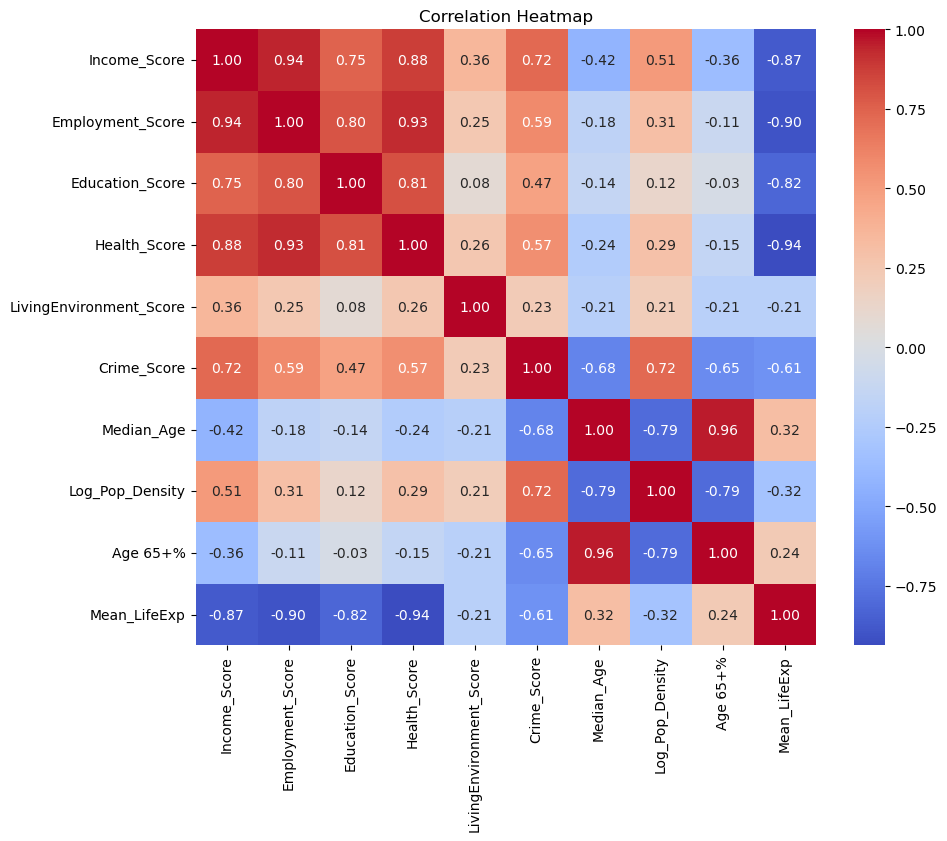

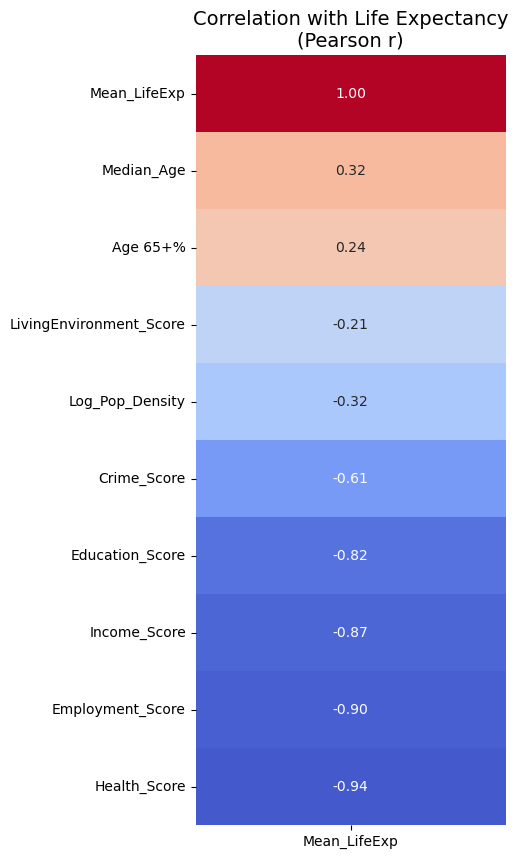

In [334]:
# Import Seaborn and the correlation libraries 
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Identify the variables you 
    # use the numeric_cols list of independent variables and controlled demographics 
    # the dependent variable is Mean_LifeExp

# Create a list to save the results to rank them later
results = []

# Loop through each variable in the numeric cols list
for col in numeric_cols:
    
    # Calculate Pearson (Linear relationship)
    p_corr, p_val = pearsonr(Main_Dataset[col], Main_Dataset['Mean_LifeExp'])
    
    # Calculate Spearman (Ranked relationship)
    s_corr, s_val = spearmanr(Main_Dataset[col], Main_Dataset['Mean_LifeExp'])
    
    # Print the results for this variable
    print(f"\nVariable: {col}")
    print(f"Pearson r: {p_corr:.3f} (p-value: {p_val:.4e})")
    print(f"Spearman r: {s_corr:.3f} (p-value: {s_val:.4e})")
    
    # Save these numbers to the list (I added 'Pearson_p' here so it doesn't crash later!)
    results.append({
        'Variable': col,
        'Pearson_r': p_corr,      # pearson correlation value 
        'Pearson_p': p_val,       # p-value for the correlation
        'Strength': abs(p_corr)})   # Rank by 'absolute' value


# Rank the variables in terms of correlation 
# Convert the list of results into a DataFrame
Ranked_Corr = pd.DataFrame(results)

# Sort from highest to lowest correlation (strongest to weakest)
Ranked_Corr = Ranked_Corr.sort_values(by='Strength', ascending=False)

# Display the results
print("RANKED BY CORRELATION STRENGTH")
print(Ranked_Corr[['Variable', 'Pearson_r', 'Pearson_p']].to_string(index=False))

# Identify the variable most weakly correlated to Mean_LifeExp
# The last row in Ranked_Corr is the weakest one
weakest = Ranked_Corr.iloc[-1]
print(f"\n>> LEAST Correlated Variable: {weakest['Variable']} (r={weakest['Pearson_r']:.3f})")

# Create a figure to make a heatmap 
plt.figure(figsize=(10, 8))

# Calculate correlation matrix for all columns (Variables + Target)
corr_matrix = Main_Dataset[numeric_cols + ['Mean_LifeExp']].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig("Correlation_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# Create a focused heatmap to show all the correlations with Mean_LifeExp
# Narrow width (4), tall height (10) to list all variables
plt.figure(figsize=(4, 10))

# Select only the 'Mean_LifeExp' column from the correlation matrix
# Sort it so the strongest positive correlations are at the top, and the negative at the bottom
heatmap_data = corr_matrix[['Mean_LifeExp']].sort_values(by='Mean_LifeExp', ascending=False)

# Create the heatmap
sns.heatmap(heatmap_data, 
            cmap='coolwarm', 
            center=0,       # Sets the middle colour (white) to 0
            annot=True,     # Show the numbers
            fmt=".2f",      # Round to 2 decimal places
            cbar=False)     # Hide the colour bar 

plt.title('Correlation with Life Expectancy\n(Pearson r)', fontsize=14)
plt.savefig("Focused_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [335]:
# Check for multicollinearity (threshold > 0.8)

# Create the matrix for just your predictors (exclude Life Expectancy)
# Use 'numeric_cols', which is defined in the previous step
feature_matrix = Main_Dataset[numeric_cols].corr()

# Loop through to find the high correlated variables 
found_issue = False

# Iterate through the columns
for i in range(len(feature_matrix.columns)):
    # Only check up to 'i' to avoid checking (A vs B) and then (B vs A) again
    for j in range(i):
        
        col_name = feature_matrix.columns[i]
        row_name = feature_matrix.columns[j]
        
        val = feature_matrix.iloc[i, j]
        
        # Use np.abs() because -0.9 is just as bad as 0.9
        if np.abs(val) > 0.8:
            print(f" WARNING: High correlation between '{row_name}' and '{col_name}' (r={val:.3f})")
            found_issue = True

if not found_issue:
    print("No multicollinearity found (no pairs > 0.8)")
else:
    print("\nACTION REQUIRED: You may need to drop one variable from each pair above for the Regression stage.")


ACTION REQUIRED: You may need to drop one variable from each pair above for the Regression stage.


SOLUTION:
- Since Median_Age and Age 65+% are highly correlated, Age 65+% will be dropped since it is less correlated to the Mean_LifeExp in comparison to Median_Age.
- LivingEnvironment_Score is also Dropped due its low Correlation with Mean_LifeExp
- For Income_Score and Employment_Score, see which variable has a bigger impact by going to 2 separate multiple regressions, one with each of the variables check for the R^2 values and see which regression model is better
- use that model and do a regression of it without the Health_Score to see if the regression is better or not

In [337]:
# Drop Age 65+% and LivingEnvironment_Score 
Main_Dataset.drop(columns=['Age65+%', 'LivingEnvironment_Score', 'Female_LifeExp', 'Male_LifeExp'], inplace=True, errors='ignore')

print("Columns dropped.")

Columns dropped.


**FEATURE ENGINEERING**

In [339]:
# Import the zscore library 
from scipy.stats import zscore

# Create Centred Median_Age
Main_Dataset['Median_Age_Centred'] = Main_Dataset['Median_Age'] - Main_Dataset['Median_Age'].mean()
print("Created 'Median_Age_Centred'")

# Create a list of IMD subdomains
imd_subdomains = [
    'Income_Score', 'Employment_Score', 'Education_Score', 
    'Health_Score', 'Crime_Score']

count = 0

# Loop through each variable in the list
for col in imd_subdomains:
    
    # Check if the column exists in the dataset before trying to process it
    if col in Main_Dataset.columns:
        # Define the new column name 
        z_col_name = f'{col}_Z'
        
        # Calculate Z-score: (Value - Mean) / Standard Deviation
        Main_Dataset[z_col_name] = zscore(Main_Dataset[col])
        count += 1
    else:
        print(f"Warning: Column '{col}' not found in dataset. Skipping.")

print(f"Processed {count} variables using Z-Score normalisation.")

# Split the Regions into more detailed geographic classification 
# Define the category map (5 Categories: North, Midlands, East, South, London)
region_map = {
    # NORTH
    'North East': 'North', 
    'North West': 'North', 
    'Yorkshire and The Humber': 'North',
    
    # MIDLANDS
    'East Midlands': 'Midlands', 
    'West Midlands': 'Midlands',
    
    # EAST
    'East of England': 'East',
    
    # SOUTH
    'South East': 'South', 
    'South West': 'South', 
    
    # LONDON
    'London': 'London'}

# Apply the map directly
# Look at the 'Region' column and convert the values based on the list above
Main_Dataset['Region_Group'] = Main_Dataset['Region'].map(region_map)
print(Main_Dataset['Region_Group'].value_counts())

Created 'Median_Age_Centred'
Processed 5 variables using Z-Score normalisation.
Region_Group
South       92
North       72
Midlands    63
East        45
London      32
Name: count, dtype: int64


# **STAGE 3: EXPLANATORY MODELLING**

**DIRECTED ACYCLIC GRAPH (DAG)**

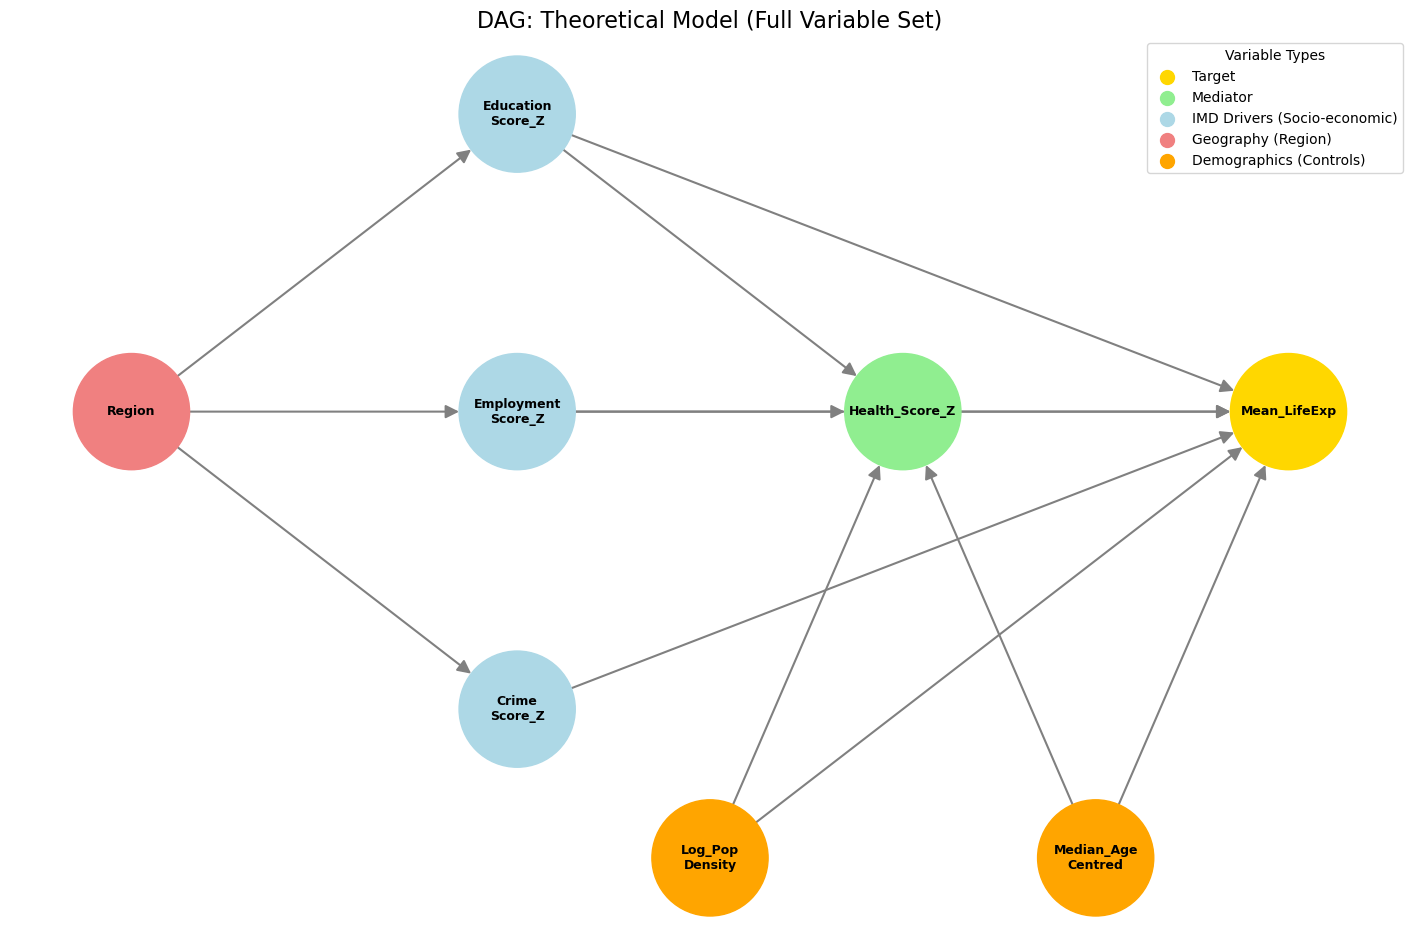

In [342]:
# Import NetworkX library 
import networkx as nx

# Initialise the graph
# Create a 'Directed Graph' (DiGraph) to model causal relationships where influence flows in one direction (arrows).
G = nx.DiGraph()

# Define the nodes (variable and colours)
# Add nodes one by one to define their position (x,y) and colour.
# 'pos' organises the logic: Left = Causes, Right = Outcome.

# The Target - Gold
G.add_node("Mean_LifeExp", pos=(4, 2), color='gold')

# The Mediator - Light Green
# This is the "bridge" between Employment and Death.
G.add_node("Health_Score_Z", pos=(3, 2), color='lightgreen')

# The IMD Subdomains (socio-economic drivers) - Light Blue
# These are the independent variables we are testing.
# Use '\n' to break the text so it fits inside the circle.
G.add_node("Employment\nScore_Z", pos=(2, 2), color='lightblue')
G.add_node("Education\nScore_Z", pos=(2, 3), color='lightblue')
G.add_node("Crime\nScore_Z", pos=(2, 1), color='lightblue')

# Geography (Structural Factor) - RED
# Represents the "North/South" divide
G.add_node("Region", pos=(1, 2), color='lightcoral')

# The controlled variables (demographics) - ORANGE
# These are background context (Age, Density) that we must control for.
G.add_node("Median_Age\nCentred", pos=(3.5, 0.5), color='orange')
G.add_node("Log_Pop\nDensity", pos=(2.5, 0.5), color='orange')


# Define the edges (arrows)
# Define the causal pathways as a list of ("Source", "Target") tuples.
edges = [
    # The Main Mediation Path: Employment -> Health -> Life Expectancy
    ("Employment\nScore_Z", "Health_Score_Z"),
    ("Health_Score_Z", "Mean_LifeExp"),
    ("Employment\nScore_Z", "Mean_LifeExp"), # Direct Effect

    # Other Drivers impacting the system
    ("Education\nScore_Z", "Health_Score_Z"),
    ("Education\nScore_Z", "Mean_LifeExp"),
    ("Crime\nScore_Z", "Mean_LifeExp"),

    # Regional Influence
    # Geography dictates where the jobs and crime are.
    ("Region", "Employment\nScore_Z"),
    ("Region", "Education\nScore_Z"),
    ("Region", "Crime\nScore_Z"),

    # Demographic Controls
    # Age and Density affect mortality directly.
    ("Median_Age\nCentred", "Mean_LifeExp"),
    ("Median_Age\nCentred", "Health_Score_Z"),
    ("Log_Pop\nDensity", "Mean_LifeExp"),
    ("Log_Pop\nDensity", "Health_Score_Z")]

# Add these connections to the graph object
G.add_edges_from(edges)


# Visualise the graph
# Extract the attributes we set above to use in the drawing function
pos = nx.get_node_attributes(G, 'pos')
colors = [nx.get_node_attributes(G, 'color')[node] for node in G.nodes()]

plt.figure(figsize=(14, 9)) # Set the canvas size

# Draw the Graph
nx.draw(G, pos, 
        with_labels=True,      # Show variable names
        node_color=colors,     # Use our custom color list
        node_size=7000,        # Make circles large enough for text
        edge_color='gray',     # Arrow color
        arrows=True,           # Ensure direction is visible
        arrowsize=20,          # Arrowhead size
        width=1.5,             # Line thickness
        font_size=9, 
        font_weight='bold')

# Create a legend
# Use 'plt.scatter' to create invisible dots just for the legend.
# This avoids the issue where the legend dots become huge (size 7000).
# s=100 sets a normal, readable size for the legend icons.
plt.scatter([], [], c='gold', s=100, label='Target')
plt.scatter([], [], c='lightgreen', s=100, label='Mediator')
plt.scatter([], [], c='lightblue', s=100, label='IMD Drivers (Socio-economic)')
plt.scatter([], [], c='lightcoral', s=100, label='Geography (Region)')
plt.scatter([], [], c='orange', s=100, label='Demographics (Controls)')

# Display the legend in the top right corner
plt.legend(loc='upper right', fontsize=10, title="Variable Types", frameon=True)

# Final formatting
plt.title("DAG: Theoretical Model (Full Variable Set)", fontsize=16)
plt.axis('off')        # Hide the box border
plt.savefig("DAG.png", dpi=300, bbox_inches='tight')
plt.show()

**MODEL 1: MULTILINEAR REGRESSION (INCL. INCOME_SCORE_Z)**

In [344]:
import statsmodels.api as sm

# Define the variables 
# Target: What we want to predict
target = 'Mean_LifeExp'

# Independent Variables: The IMD Socio-economic factors we are testing
# Group Income with Education and Crime because they are all deprivation measures.
independent_vars = [
    'Income_Score_Z',      # The Main Driver we are testing
    'Education_Score_Z', 
    'Crime_Score_Z']

# Controlled Variables: The Demographic Context
# These are purely population stats, not deprivation scores.
controlled_vars = ['Log_Pop_Density', 'Median_Age_Centred']

# Prepare the data
# Combine everything into one list for the regression
all_X_vars = independent_vars + controlled_vars

# Create the X dataset
X_income = Main_Dataset[all_X_vars]

# Add the Constant (Intercept)
X_income = sm.add_constant(X_income)

# Define Y
Y = Main_Dataset[target]

# Run the regression 
# OLS = Ordinary Least Squares
model_income = sm.OLS(Y, X_income, missing='drop').fit()

# Generate the Results 
print(model_income.summary())

# Check the R-Squared
print(f"\n>> Adjusted R-Squared: {model_income.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     287.7
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          9.28e-112
Time:                        15:08:59   Log-Likelihood:                -274.95
No. Observations:                 304   AIC:                             561.9
Df Residuals:                     298   BIC:                             584.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 80.7661      0

**MODEL 2: MULTILINEAR REGRESSION (INCL. EMPLOYMENT_SCORE_Z)**

In [346]:
# Define the variables 
# Target = 'Mean_LifeExp' as set up previously 

# Independent Variables: The IMD Socio-economic factors we are testing
# We group Employment with Education and Crime.
independent_vars = [
    'Employment_Score_Z',   # The Main Driver we are testing here
    'Education_Score_Z', 
    'Crime_Score_Z']

# controlled_vars = ['Log_Pop_Density', 'Median_Age_Centered'] as set up previously 

# Prepare the data 
# Combine everything into one list for the regression
all_X_vars = independent_vars + controlled_vars

# Create the X dataset
X_employ = Main_Dataset[all_X_vars]

# Add the Constant (Intercept)
X_employ = sm.add_constant(X_employ)

# Define Y
Y = Main_Dataset[target]

# Run teh regression
# Fit the model
model_employ = sm.OLS(Y, X_employ, missing='drop').fit()

# Generate the results 
print(model_employ.summary())

# Specifically look at Adjusted R-squared
print(f"\n>> Adjusted R-Squared: {model_employ.rsquared_adj:.4f}")

# Compare with Model 1 
# We compare this result against the Income Model (which was ~0.826)
if model_employ.rsquared_adj > 0.826:
    print(">> EMPLOYMENT is the stronger predictor.")
else:
    print(">> INCOME is the stronger predictor.")

                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     399.7
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          8.06e-130
Time:                        15:08:59   Log-Likelihood:                -232.45
No. Observations:                 304   AIC:                             476.9
Df Residuals:                     298   BIC:                             499.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 80.6306      0

**MODEL 3: MULTILINEAR REGRESSION (INCL. EMPLOYMENT_SCORE_Z + Health_Score_Z)**

In [348]:
# 1. DEFINE VARIABLES
# Target = 'Mean_LifeExp' as previously set up 

# Independent Variables - include Health_Score in this 
independent_vars = [
    'Employment_Score_Z', 
    'Health_Score_Z', 
    'Education_Score_Z', 
    'Crime_Score_Z']

# controlled_vars = ['Log_Pop_Density', 'Median_Age_Centered'] as set up previously 

# Prepare the data 
# Combine everything into one list for the regression
all_X_vars = independent_vars + controlled_vars

# Create the X dataset
X = Main_Dataset[all_X_vars]

# Add the Constant (Intercept)
X = sm.add_constant(X)

# Define Y
Y = Main_Dataset[target]

# Run the regression
model_3 = sm.OLS(Y, X, missing='drop').fit()

# Generate the results
print(model_3.summary())

# Check the new R-Squared
print(f"\n>> Adjusted R-Squared: {model_3.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     487.9
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          1.47e-150
Time:                        15:08:59   Log-Likelihood:                -180.37
No. Observations:                 304   AIC:                             374.7
Df Residuals:                     297   BIC:                             400.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 80.9033      0

**MODEL 4: MULTILINEAR REGRESSION OF THE NORTH/SOUTH (SVM)**

In [350]:
# Define the variables
# target = 'Mean_LifeExp' as set up previously

# The Main Drivers - independent_vars = ['Employment_Score_Z', 'Health_Score_Z', 'Education_Score_Z', 'Crime_Score_Z'] as set up previously

# controlled_vars = ['Log_Pop_Density', 'Median_Age_Centered'] as set up previously 

# Set up the geographic data 
# Use 'Geo_Location' variable derived from the SVM.
# Map 'South' to 0 (Baseline) and 'North' to 1.
# The coefficient for 'North' will show the difference relative to the South.
Main_Dataset['North'] = Main_Dataset['Geo_Location'].map({'South': 0, 'North': 1})

# Combine standard variables with the new binary location variable
X_standard = Main_Dataset[independent_vars + controlled_vars]

# Add the binary location column
X_final = pd.concat([X_standard, Main_Dataset['North']], axis=1)

# Add Constant (Intercept)
X_final = sm.add_constant(X_final)

# Define Y
Y = Main_Dataset[target]

# Run the regression
# Fit the Ordinary Least Squares (OLS) model
model_4 = sm.OLS(Y, X_final, missing='drop').fit()

# Display the full statistical table
print(model_4.summary())


                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     454.4
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          2.97e-154
Time:                        15:08:59   Log-Likelihood:                -168.39
No. Observations:                 304   AIC:                             352.8
Df Residuals:                     296   BIC:                             382.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 81.2904      0

**MODEL 5: MULTILINEAR REGRESSION OF THE SMALLER REGIONS**

In [352]:
# Define the variables
# target = 'Mean_LifeExp' as set up previously

# The Main Drivers - independent_vars = ['Employment_Score_Z', 'Health_Score_Z', 'Education_Score_Z', 'Crime_Score_Z'] as set up previously

# controlled_vars = ['Log_Pop_Density', 'Median_Age_Centered'] as set up previously 

# Set up the geographic data
# Convert text regions (North, South, etc.) into numerical 'Dummy Variables' (0 or 1).
# Drop_first=True removes 'East of England' alphabetically.
# 'East' becomes the invisible BASELINE against which all other regions are compared.
region_dummies = pd.get_dummies(Main_Dataset['Region_Group'], drop_first=True, dtype=float)


# Build the regression model 
# Combine standard variables with the new region dummies
X_standard = Main_Dataset[independent_vars + controlled_vars]
X_final = pd.concat([X_standard, region_dummies], axis=1)

# Add Constant (Intercept) to capture the baseline life expectancy
X_final = sm.add_constant(X_final)

# Define Y
Y = Main_Dataset[target]

# Run the regression 
# Fit the Ordinary Least Squares (OLS) model
# missing='drop' ensures towns with incomplete data don't crash the model
model_5 = sm.OLS(Y, X_final, missing='drop').fit()

# Display the full statistical table
print(model_5.summary())


                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     321.3
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          1.75e-151
Time:                        15:08:59   Log-Likelihood:                -165.58
No. Observations:                 304   AIC:                             353.2
Df Residuals:                     293   BIC:                             394.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 81.3739      0

# **STAGE 4: ANALYSIS, INTERPRETATION, AND VALIDATION**

**MODEL 3 DIAGNOSTICS**


Variance Inflation Factors (VIF):
             Variable        VIF
0               const  86.969232
1  Employment_Score_Z   9.507558
2      Health_Score_Z   8.432369
5     Log_Pop_Density   3.816704
6  Median_Age_Centred   3.673707
4       Crime_Score_Z   3.672592
3   Education_Score_Z   3.502968


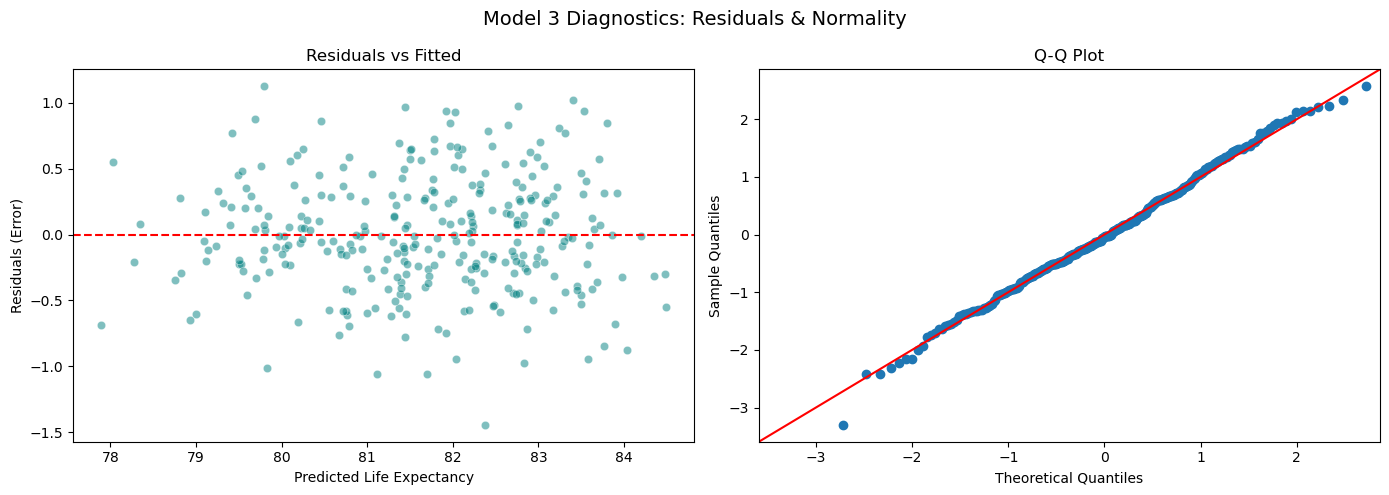


Breusch-Pagan Test:
Breusch-Pagan p-value: 0.1311
>> PASS: Homoscedasticity Confirmed.


In [355]:
#Import VIF library to test multicollinearity 
from statsmodels.stats.outliers_influence import variance_inflation_factor
#Import Breusch pagan library to test for heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan 
#Import QQplot library to check for normality
from statsmodels.graphics.gofplots import qqplot         


# Check for multicollinearity through VIF test 
# Purpose: Check if variables like 'Health' and 'Employment' are too similar.
# If VIF > 5, they are fighting each other. If VIF > 10, one must be removed.

print("\nVariance Inflation Factors (VIF):")

# Create a dataframe to store VIF results
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

# Calculate VIF for each variable in the X dataset
# Loop through every column in X and calculate its score
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Print the table sorted by VIF score (highest to lowest)
print(vif_data.sort_values(by="VIF", ascending=False))


# Create Residual Plots 
# Purpose: Visualising the errors (residuals) to see if the model is biased.

# Get the errors (residuals) and the predictions from model_3
residuals = model_3.resid
fitted_values = model_3.fittedvalues

# Create a plotting area with 2 graphs side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 3 Diagnostics: Residuals & Normality', fontsize=14)

# Graph A: Residuals vs Fitted Values
# We want a random cloud of dots around the red line.
# A "U" shape suggests that the model is missing a curve.
# A "Cone" shape suggests that the error variance is getting worse (Heteroscedasticity).
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0], alpha=0.5, color='teal')
ax[0].axhline(0, color='red', linestyle='--') # The zero line (perfect prediction)
ax[0].set_title('Residuals vs Fitted')
ax[0].set_xlabel('Predicted Life Expectancy')
ax[0].set_ylabel('Residuals (Error)')

# Graph B: Q-Q Plot (Normality)
# The dots should follow the red 45-degree line. 
# If dots curve off at the ends, the model is failing on extreme Local authorities (very rich or poor).
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q-Q Plot')

plt.tight_layout() # Fix layout spacing
plt.show()         # Display the plots


# Run the Bruesch-Pagan Test for Heteroskedasticity
# Purpose: use statistical methods to confirm if the visual "Cone" shape (Heteroscedasticity) is significant.
print("\nBreusch-Pagan Test:")

# Run the Breusch-Pagan test on the residuals
bp_test = het_breuschpagan(residuals, X)
bp_pvalue = bp_test[1] # The second value is the p-value

print(f"Breusch-Pagan p-value: {bp_pvalue:.4f}")

# Interpret the result
if bp_pvalue < 0.05:
    print(">> WARNING: Heteroscedasticity Detected (p < 0.05).")
else:
    print(">> PASS: Homoscedasticity Confirmed.")

**MODEL 4 DIAGNOSTICS**


Variance Inflation Factors (VIF):
              Variable         VIF
0                const  114.980262
1   Employment_Score_Z   10.875766
2       Health_Score_Z    9.677400
3    Education_Score_Z    4.846548
5      Log_Pop_Density    4.743925
4        Crime_Score_Z    3.909433
6   Median_Age_Centred    3.861485
9                North    3.123943
7               London    2.509872
10               South    2.248581
8             Midlands    2.150510


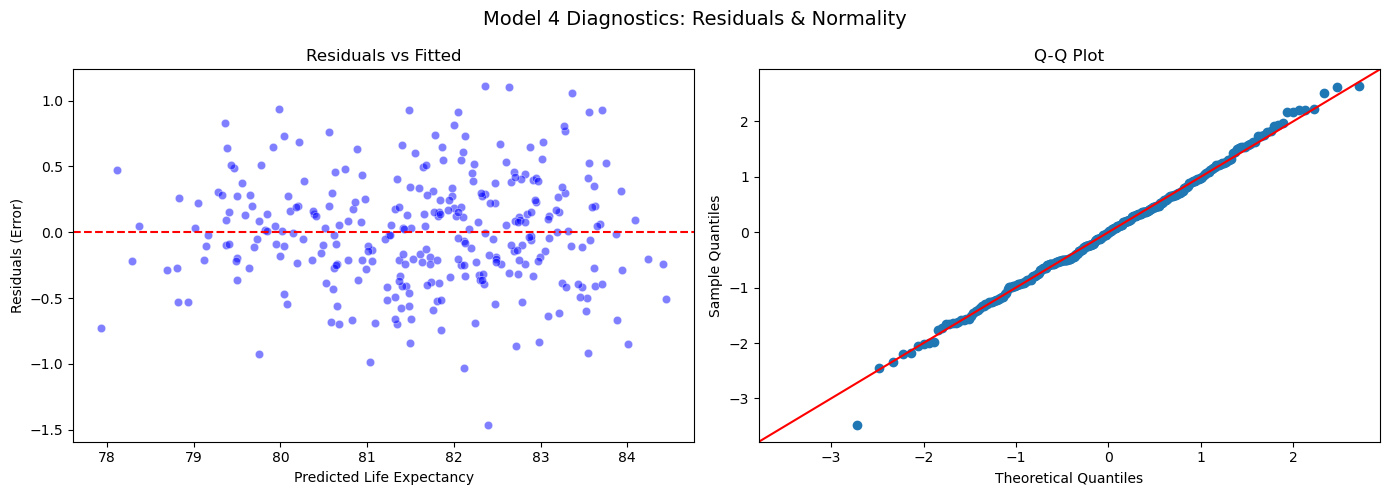


Breusch-Pagan Test:
Breusch-Pagan p-value: 0.0283
>> WARNING: Heteroscedasticity Detected (p < 0.05).


In [357]:
# Check for multicollinearity through VIF test 
print("\nVariance Inflation Factors (VIF):")

# Create a dataframe to store VIF results
vif_data = pd.DataFrame()
vif_data["Variable"] = X_final.columns

# Calculate VIF for each variable in the X_final dataset
vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

# Print the table sorted by VIF score (highest to lowest)
print(vif_data.sort_values(by="VIF", ascending=False))


# Create Residual Plots 
# Get the errors (residuals) and predictions from your existing model_4
residuals = model_4.resid
fitted_values = model_4.fittedvalues

# Create a plotting area with 2 graphs side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 4 Diagnostics: Residuals & Normality', fontsize=14)

# Graph A: Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0], alpha=0.5, color='blue')
ax[0].axhline(0, color='red', linestyle='--') # The zero line (perfect prediction)
ax[0].set_title('Residuals vs Fitted')
ax[0].set_xlabel('Predicted Life Expectancy')
ax[0].set_ylabel('Residuals (Error)')

# Graph B: Q-Q Plot (Normality)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q-Q Plot')

plt.tight_layout() # Fix layout spacing
plt.show()         # Display the plots


# Run the Bruesch-Pagan Test for Heteroskedasticity
print("\nBreusch-Pagan Test:")

# Run the Breusch-Pagan test on the residuals to check for Heteroskedasticity
bp_test = het_breuschpagan(residuals, X_final)
bp_pvalue = bp_test[1] # The second value is the p-value

print(f"Breusch-Pagan p-value: {bp_pvalue:.4f}")

# Interpret the result
if bp_pvalue < 0.05:
    print(">> WARNING: Heteroscedasticity Detected (p < 0.05).")
else:
    print(">> PASS: Homoscedasticity Confirmed.")

**MODEL 5 DIAGNOSTICS**


Variance Inflation Factors (VIF):
              Variable         VIF
0                const  114.980262
1   Employment_Score_Z   10.875766
2       Health_Score_Z    9.677400
3    Education_Score_Z    4.846548
5      Log_Pop_Density    4.743925
4        Crime_Score_Z    3.909433
6   Median_Age_Centred    3.861485
9                North    3.123943
7               London    2.509872
10               South    2.248581
8             Midlands    2.150510


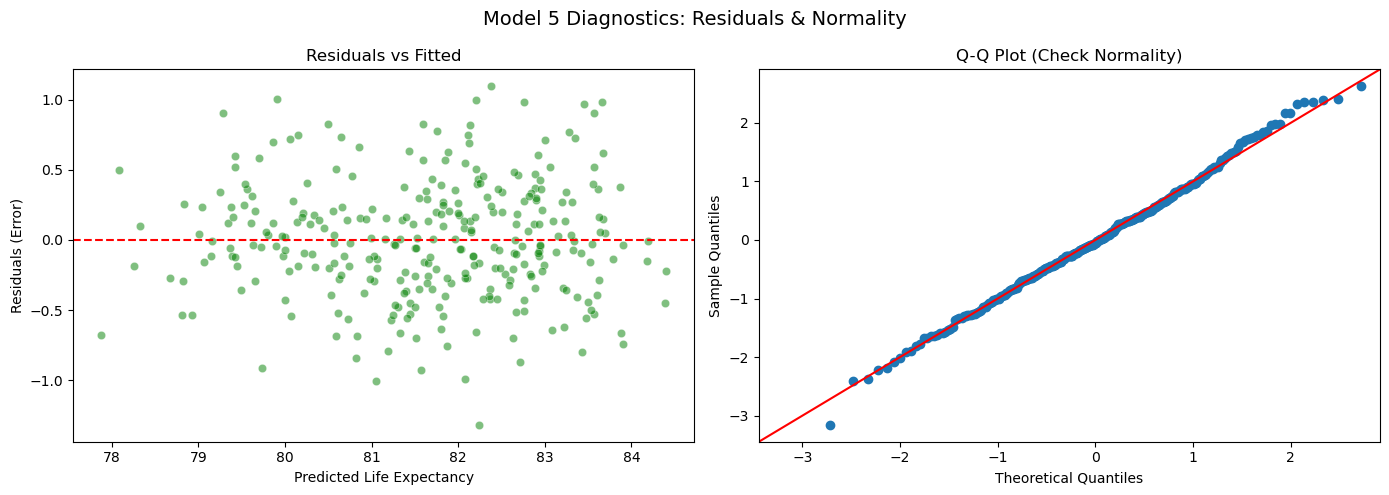


Breusch-Pagan Test:
Breusch-Pagan p-value: 0.0415
>> WARNING: Heteroscedasticity Detected.


In [359]:
# Check for multicollinearity through VIF test 
print("\nVariance Inflation Factors (VIF):")

# Create a dataframe to store VIF results
vif_data = pd.DataFrame()

# NOTE: Ensure 'X_final' is the name of the X variable you used for Model 5
vif_data["Variable"] = X_final.columns 

# Calculate VIF for each variable
vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

# Print the table sorted by VIF score (highest to lowest)
print(vif_data.sort_values(by="VIF", ascending=False))

# Create Residual Plots 
# Get the errors (residuals) and predictions from model_5
residuals = model_5.resid
fitted_values = model_5.fittedvalues

# Create a plotting area with 2 graphs side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 5 Diagnostics: Residuals & Normality', fontsize=14)

# Graph A: Residuals vs Fitted Values
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0], alpha=0.5, color='green')
ax[0].axhline(0, color='red', linestyle='--') # The zero line
ax[0].set_title('Residuals vs Fitted')
ax[0].set_xlabel('Predicted Life Expectancy')
ax[0].set_ylabel('Residuals (Error)')

# Graph B: Q-Q Plot (Normality)
qqplot(residuals, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q-Q Plot (Check Normality)')
plt.tight_layout()
plt.show()


# Run the Breusch-Pagan test on the residuals to check for Heteroskedasticity
# Purpose: Test if the variance is constant across all these different regions.
print("\nBreusch-Pagan Test:")

# Run the Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X_final)
bp_pvalue = bp_test[1]

print(f"Breusch-Pagan p-value: {bp_pvalue:.4f}")

if bp_pvalue < 0.05:
    print(">> WARNING: Heteroscedasticity Detected.")
else:
    print(">> PASS: Homoscedasticity Confirmed.")

**MODEL 4 REGRESSION: ROBUST STANDARD ERRORS**

In [361]:
# Access the already fitted model_4 and apply HC3 Robust Standard Errors
# HC3 is chosen as the most conservative estimator for heteroscedasticity.
model_4_robust = model_4.get_robustcov_results(cov_type='HC3')

# Display the updated statistical table
print(model_4_robust.summary())

                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     465.9
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          1.02e-155
Time:                        15:09:01   Log-Likelihood:                -168.39
No. Observations:                 304   AIC:                             352.8
Df Residuals:                     296   BIC:                             382.5
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 81.2904      0

**MODEL 5 REGRESSION: ROBUST STANDARD ERRORS**

In [363]:
# Access the already fitted model_4 and apply HC3 Robust Standard Errors
# HC3 is chosen as the most conservative estimator for heteroscedasticity.
model_5_robust = model_5.get_robustcov_results(cov_type='HC3')

# Display the updated statistical table
print(model_5_robust.summary())

                            OLS Regression Results                            
Dep. Variable:           Mean_LifeExp   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                     332.7
Date:                Sun, 21 Dec 2025   Prob (F-statistic):          1.65e-153
Time:                        15:09:02   Log-Likelihood:                -165.58
No. Observations:                 304   AIC:                             353.2
Df Residuals:                     293   BIC:                             394.1
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 81.3739      0